# DBS Filter Diagnostic & Pipeline Visualization
## Complete Test of All Filter Methods with Stage-by-Stage Plots

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
import mne
from pathlib import Path
import sys
import re
import importlib

# Add source to path and reload local modules so notebook reflects latest edits
sys.path.insert(0, '/Users/student/Workspace/ml-driven-eeg-biomarkers')
import src.filters as filters_mod
import src.preprocessing as preproc_mod
importlib.reload(filters_mod)
importlib.reload(preproc_mod)

from src.filters import ArtifactFilterFactory
from src.preprocessing import EEGPreprocessor

plt.style.use('seaborn-v0_8-darkgrid')
mne.set_log_level('WARNING')

# Database-wide frequency constraints
MAX_FREQ = 119.0
BANDPASS_LOW = 1.0
BANDPASS_HIGH = 110.0

def infer_target_from_filename(name: str):
    nums = [float(x) for x in re.findall(r'\d+', name)]
    valid = [x for x in nums if 0 < x < MAX_FREQ]
    return valid[0] if valid else None

print('✓ Imports complete')
print(f'✓ Frequency policy: all analysis/filtering below {MAX_FREQ} Hz')

✓ Imports complete
✓ Frequency policy: all analysis/filtering below 119.0 Hz


## 2. Load Sample DBS Signal Data

In [2]:
data_dir = Path('/Users/student/Workspace/ml-driven-eeg-biomarkers/data/XU')
edf_files = sorted(list(data_dir.glob('*.edf')))

print(f'Found {len(edf_files)} EDF files:')
for i, f in enumerate(edf_files, 1):
    print(f'  {i}. {f.name}')

# Force DBS test file to 7 Hz recording
preferred_dbs = next((f for f in edf_files if 'XUAWAKE7' in f.stem.upper()), None)
if preferred_dbs is None:
    preferred_dbs = next((f for f in edf_files if re.search(r'(^|[^0-9])7([^0-9]|$)', f.stem)), None)
if preferred_dbs is None:
    raise RuntimeError('No 7 Hz DBS file found in data/XU.')

# Baseline reference for preserving brain activity at 7/14/... Hz
preferred_baseline = next((f for f in edf_files if 'XUAWAKEPRE' in f.stem.upper()), None)
if preferred_baseline is None:
    preferred_baseline = next((f for f in edf_files if f.stem.upper() == 'XUSLEEP_DEIDENTIFIED'), None)
if preferred_baseline is None:
    raise RuntimeError('No baseline file found (expected XUAWAKEPRE or XUSLEEP).')

test_file = preferred_dbs
baseline_file = preferred_baseline

raw = mne.io.read_raw_edf(test_file, preload=True, verbose='WARNING')
baseline_raw = mne.io.read_raw_edf(baseline_file, preload=True, verbose='WARNING')
raw_orig = raw.copy()
raw_work = raw.copy()

sfreq = float(raw.info['sfreq'])
nyquist = sfreq / 2.0
analysis_fmax = min(MAX_FREQ, nyquist - 0.5)

# Fixed target: DBS stimulation frequency for this test
dbs_target_freq = 7.0

print(f'\nDBS file: {test_file.name}')
print(f'Baseline file: {baseline_file.name}')
print(f'✓ Sampling rate: {sfreq:.1f} Hz (Nyquist {nyquist:.1f} Hz)')
print(f'✓ Analysis upper bound: {analysis_fmax:.1f} Hz')
print(f'✓ DBS target frequency: {dbs_target_freq:.2f} Hz')
print(f"✓ DBS channels: {raw.info['nchan']}")
print(f"✓ Baseline channels: {baseline_raw.info['nchan']}")

Found 8 EDF files:
  1. XUAWAKE60_deidentified.edf
  2. XUAWAKE7_deidentified.edf
  3. XUAWAKEPRE_deidentified.edf
  4. XUAWAKET100_deidentified.edf
  5. XUSLEEP60_deidentified.edf
  6. XUSLEEP7_deidentified.edf
  7. XUSLEEPT100_deidentified.edf
  8. XUSLEEP_deidentified.edf

DBS file: XUAWAKE7_deidentified.edf
Baseline file: XUAWAKEPRE_deidentified.edf
✓ Sampling rate: 256.0 Hz (Nyquist 128.0 Hz)
✓ Analysis upper bound: 119.0 Hz
✓ DBS target frequency: 7.00 Hz
✓ DBS channels: 46
✓ Baseline channels: 34


## 3. Inspect Raw Signal (Before Filtering)

/var/folders/18/40n2bscx0213zlwjwsk57bm40000gn/T/ipykernel_78836/878533903.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


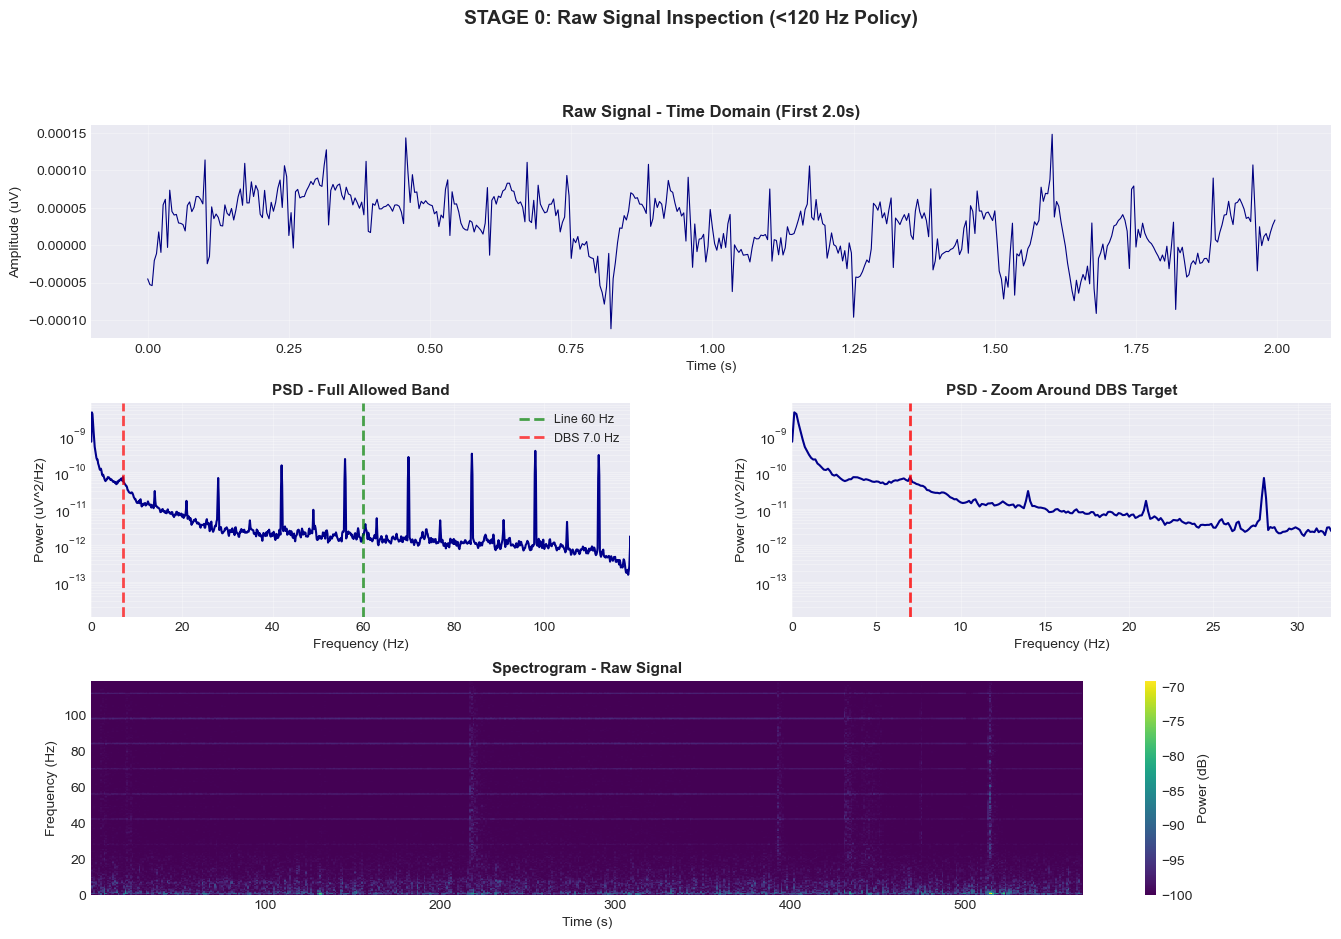

✓ Raw signal visualization complete


In [3]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

data_raw = raw_orig.get_data()
t = raw_orig.times
ch_idx = 0

ax1 = fig.add_subplot(gs[0, :])
t_crop = 2.0
crop_idx = int(t_crop * sfreq)
ax1.plot(t[:crop_idx], data_raw[ch_idx, :crop_idx], linewidth=0.8, color='navy')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude (uV)')
ax1.set_title(f'Raw Signal - Time Domain (First {t_crop}s)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

freqs, pxx = signal.welch(data_raw[ch_idx], fs=sfreq, nperseg=min(2048, data_raw.shape[1]), window='hann')

ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(freqs, pxx, linewidth=1.5, color='darkblue')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Power (uV^2/Hz)')
ax2.set_title('PSD - Full Allowed Band', fontsize=11, fontweight='bold')
ax2.set_xlim([0, analysis_fmax])
for hz, c, label in [(60, 'green', 'Line 60 Hz'), (dbs_target_freq, 'red', f'DBS {dbs_target_freq:.1f} Hz')]:
    if hz < analysis_fmax:
        ax2.axvline(x=hz, color=c, linestyle='--', linewidth=2, alpha=0.7, label=label)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, which='both')

ax3 = fig.add_subplot(gs[1, 1])
ax3.semilogy(freqs, pxx, linewidth=1.5, color='darkblue')
ax3.set_xlabel('Frequency (Hz)')
ax3.set_ylabel('Power (uV^2/Hz)')
ax3.set_title('PSD - Zoom Around DBS Target', fontsize=11, fontweight='bold')
left = max(0, dbs_target_freq - 25)
right = min(analysis_fmax, dbs_target_freq + 25)
ax3.set_xlim([left, right])
ax3.axvline(x=dbs_target_freq, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax3.grid(True, alpha=0.3, which='both')

ax4 = fig.add_subplot(gs[2, :])
f, t_sg, Sxx = signal.spectrogram(data_raw[ch_idx], fs=sfreq, window='hann', nperseg=512, noverlap=256, nfft=1024)
im = ax4.pcolormesh(t_sg, f, 10 * np.log10(Sxx + 1e-10), shading='auto', cmap='viridis')
ax4.set_ylabel('Frequency (Hz)')
ax4.set_xlabel('Time (s)')
ax4.set_ylim([0, analysis_fmax])
ax4.set_title('Spectrogram - Raw Signal', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax4, label='Power (dB)')

plt.suptitle('STAGE 0: Raw Signal Inspection (<120 Hz Policy)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print('✓ Raw signal visualization complete')

## 4. Apply Preprocessing Pipeline Steps

In [4]:
print('[1/4] Standardizing channels (DBS + baseline)...')
preprocessor = EEGPreprocessor(
    l_freq=BANDPASS_LOW,
    h_freq=BANDPASS_HIGH,
    dbs_freqs=[7.0, 60.0, 100.0],
    generate_plots=False
)

raw_standardized = preprocessor.standardize_channels(raw_work.copy())
baseline_standardized = preprocessor.standardize_channels(baseline_raw.copy())

# Keep only intersection channels and consistent order
common_ch = [ch for ch in raw_standardized.ch_names if ch in baseline_standardized.ch_names]
if len(common_ch) < 4:
    raise RuntimeError(f'Not enough overlapping channels between DBS and baseline: {len(common_ch)}')

raw_standardized.pick(common_ch)
baseline_standardized.pick(common_ch)
print(f'  ✓ Common channels used: {len(common_ch)}')

# Match sampling rates if needed
if baseline_standardized.info['sfreq'] != raw_standardized.info['sfreq']:
    baseline_standardized.resample(raw_standardized.info['sfreq'], verbose='WARNING')
    print(f"  ✓ Baseline resampled to {raw_standardized.info['sfreq']:.1f} Hz")

print(f'[2/4] Applying clinical bandpass ({BANDPASS_LOW}-{BANDPASS_HIGH} Hz)...')
raw_bandpass = raw_standardized.copy()
baseline_bandpass = baseline_standardized.copy()
raw_bandpass.filter(l_freq=BANDPASS_LOW, h_freq=min(BANDPASS_HIGH, analysis_fmax), fir_design='firwin', phase='zero', verbose='WARNING')
baseline_bandpass.filter(l_freq=BANDPASS_LOW, h_freq=min(BANDPASS_HIGH, analysis_fmax), fir_design='firwin', phase='zero', verbose='WARNING')
print('  ✓ Bandpass complete for DBS and baseline')

print('[3/4] Applying line-noise notch filters (keep 7/14 Hz intact)...')
notch_freqs = [f for f in [60, 100] if f < analysis_fmax]
raw_notch = raw_bandpass.copy()
baseline_proc = baseline_bandpass.copy()
if notch_freqs:
    raw_notch.notch_filter(freqs=notch_freqs, fir_design='firwin', phase='zero', verbose='WARNING')
    baseline_proc.notch_filter(freqs=notch_freqs, fir_design='firwin', phase='zero', verbose='WARNING')
print(f'  ✓ Notch frequencies used: {notch_freqs}')

print('[4/4] Ready for baseline-referenced DBS suppression at 7 Hz harmonics')
print('\n✓ Preprocessing complete under <120 Hz constraint')

[1/4] Standardizing channels (DBS + baseline)...
  ✓ Common channels used: 19
  ✓ Baseline resampled to 256.0 Hz
[2/4] Applying clinical bandpass (1.0-110.0 Hz)...
  ✓ Bandpass complete for DBS and baseline
[3/4] Applying line-noise notch filters (keep 7/14 Hz intact)...
  ✓ Notch frequencies used: [60, 100]
[4/4] Ready for baseline-referenced DBS suppression at 7 Hz harmonics

✓ Preprocessing complete under <120 Hz constraint


## 5. Visualize Each Filter Stage

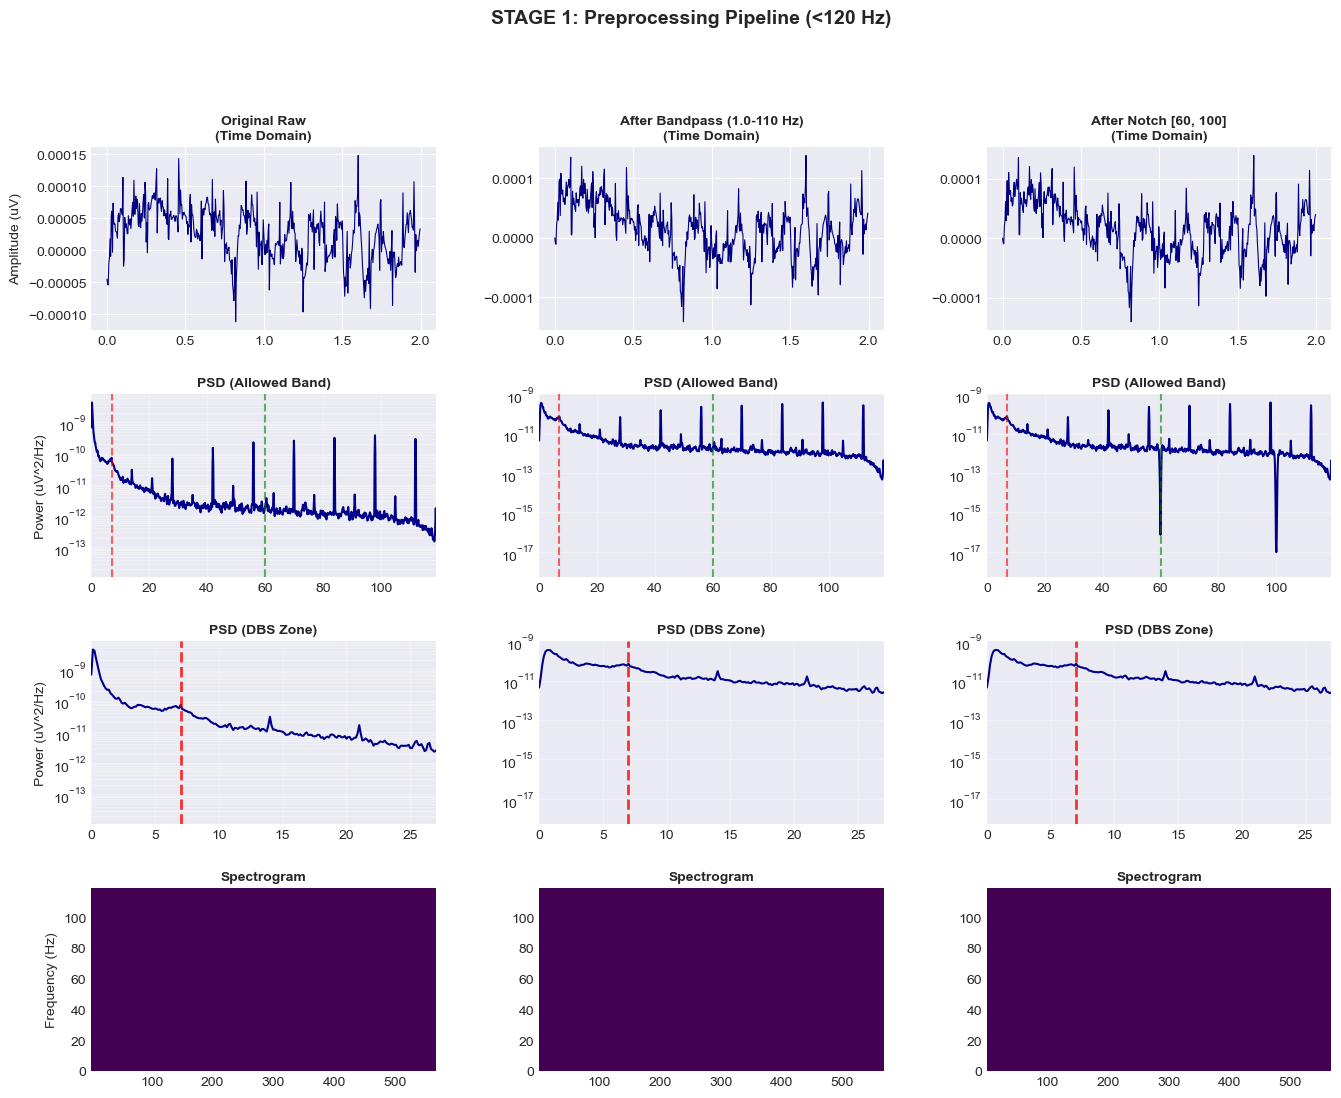

✓ Preprocessing stage visualization complete


In [5]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.35, wspace=0.3)

stages = [
    (raw_orig, 'Original Raw'),
    (raw_bandpass, f'After Bandpass ({BANDPASS_LOW}-{min(BANDPASS_HIGH, analysis_fmax):.0f} Hz)'),
    (raw_notch, f'After Notch {notch_freqs}')
]

for stage_idx, (raw_s, title) in enumerate(stages):
    data = raw_s.get_data()[0]

    ax1 = fig.add_subplot(gs[0, stage_idx])
    t_crop = 2.0
    crop_idx = int(t_crop * sfreq)
    ax1.plot(raw_s.times[:crop_idx], data[:crop_idx], linewidth=0.8, color='navy')
    ax1.set_title(f'{title}\n(Time Domain)', fontsize=10, fontweight='bold')
    if stage_idx == 0:
        ax1.set_ylabel('Amplitude (uV)', fontsize=10)

    ax2 = fig.add_subplot(gs[1, stage_idx])
    freqs, pxx = signal.welch(data, fs=sfreq, nperseg=min(2048, len(data)), window='hann')
    ax2.semilogy(freqs, pxx, linewidth=1.5, color='darkblue')
    ax2.set_title('PSD (Allowed Band)', fontsize=10, fontweight='bold')
    ax2.set_xlim([0, analysis_fmax])
    for hz, c in [(60, 'green'), (dbs_target_freq, 'red')]:
        if hz < analysis_fmax:
            ax2.axvline(x=hz, color=c, linestyle='--', alpha=0.6, linewidth=1.5)
    ax2.grid(True, alpha=0.3, which='both')
    if stage_idx == 0:
        ax2.set_ylabel('Power (uV^2/Hz)', fontsize=10)

    ax3 = fig.add_subplot(gs[2, stage_idx])
    ax3.semilogy(freqs, pxx, linewidth=1.5, color='darkblue')
    left = max(0, dbs_target_freq - 20)
    right = min(analysis_fmax, dbs_target_freq + 20)
    ax3.set_xlim([left, right])
    ax3.set_title('PSD (DBS Zone)', fontsize=10, fontweight='bold')
    ax3.axvline(x=dbs_target_freq, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax3.grid(True, alpha=0.3, which='both')
    if stage_idx == 0:
        ax3.set_ylabel('Power (uV^2/Hz)', fontsize=10)

    ax4 = fig.add_subplot(gs[3, stage_idx])
    f_s, t_s, Sxx_s = signal.spectrogram(data, fs=sfreq, window='hann', nperseg=512, noverlap=256, nfft=1024)
    ax4.pcolormesh(t_s, f_s, 10 * np.log10(Sxx_s + 1e-10), shading='auto', cmap='viridis', vmin=-60, vmax=20)
    ax4.set_ylim([0, analysis_fmax])
    ax4.set_title('Spectrogram', fontsize=10, fontweight='bold')
    if stage_idx == 0:
        ax4.set_ylabel('Frequency (Hz)', fontsize=10)

plt.suptitle('STAGE 1: Preprocessing Pipeline (<120 Hz)', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print('✓ Preprocessing stage visualization complete')

## 6. Test All DBS Filter Methods

In [6]:
filter_methods = {
    'wiener_baseline': {
        'params': {
            'dbs_freq': float(dbs_target_freq),
            'harmonic_bandwidth': 1.5,
            'n_fft': 2048,
            'floor_db': -18.0,
            'alpha': 1.50,
            'taper_width': 1.0
        },
        'description': 'Wiener Baseline-Referenced (preservation-focused)'
    },
    'spectrum_fit': {
        'params': {'f_target': float(dbs_target_freq), 'bandwidth': 1.5, 'attenuation_db': -35.0},
        'description': 'Spectrum-Fit (Multi-Harmonic)'
    },
    'hampel_freq': {
        'params': {'window_hz': 2.0, 'n_sigmas': 3.0, 'attenuation_db': -35.0},
        'description': 'Hampel Filter (Frequency Domain)'
    },
    'hampel_time': {
        'params': {'window_sec': 0.2, 'n_sigmas': 3.0, 'attenuation_factor': 1.0},
        'description': 'Hampel Filter (Time Domain)'
    },
    'zapline': {
        'params': {'f_target': float(dbs_target_freq), 'n_harmonics': 12, 'threshold_percentile': 95.0},
        'description': 'Zapline+ (Spatial Filtering)'
    },
    'comb_notch': {
        'params': {'f0': float(dbs_target_freq), 'q_factor': 35.0},
        'description': 'Comb Notch Filter'
    }
}

filtered_results = {}
for method_name, method_config in filter_methods.items():
    try:
        print(f"Testing {method_config['description']}...", end=' ')

        if method_name == 'wiener_baseline':
            raw_filtered = preprocessor.remove_artifacts_baseline(
                raw_notch.copy(),
                baseline_proc.copy(),
                **method_config['params']
            )
        else:
            raw_filtered = raw_notch.copy()
            raw_filtered.load_data()
            data = raw_filtered.get_data()
            cleaned_data = ArtifactFilterFactory.process(
                method=method_name,
                data=data,
                sfreq=sfreq,
                **method_config['params']
            )
            raw_filtered._data = cleaned_data

        filtered_results[method_name] = raw_filtered
        print('✓')
    except Exception as e:
        print(f'✗ Error: {str(e)[:120]}')
        filtered_results[method_name] = None

ok = sum(1 for v in filtered_results.values() if v is not None)
print(f'\n✓ Testing complete. {ok}/{len(filter_methods)} methods succeeded for 7 Hz DBS')

Testing Wiener Baseline-Referenced (preservation-focused)... Baseline-Referenced Wiener Filter: f0=7.0 Hz, bandwidth=1.5 Hz (+1.0 Hz taper), alpha=1.5, n_fft=2048
     7.0 Hz: median attenuation = +0.0 dB
    14.0 Hz: median attenuation = -0.0 dB
    21.0 Hz: median attenuation = -0.1 dB
    28.0 Hz: median attenuation = -1.5 dB
    35.0 Hz: median attenuation = -0.4 dB
    42.0 Hz: median attenuation = -2.0 dB
    49.0 Hz: median attenuation = -1.8 dB
    56.0 Hz: median attenuation = -2.1 dB
    63.0 Hz: median attenuation = -2.2 dB
    70.0 Hz: median attenuation = -2.8 dB
✓
Testing Spectrum-Fit (Multi-Harmonic)... Applying Spectrum-Fit Multi-Harmonic Removal (f=7.0Hz, bandwidth=1.5Hz, attenuation=-35.0dB)
✓
Testing Hampel Filter (Frequency Domain)... Running vectorized Freq-Domain Hampel (Allen et al., 2010) - window=2.0Hz, sigmas=3.0, attenuation=-35.0dB
Replaced 30444 frequency domain spikes.
✓
Testing Hampel Filter (Time Domain)... Running vectorized Time-Domain Hampel (Allen et

## 7. Compare All Filter Outputs

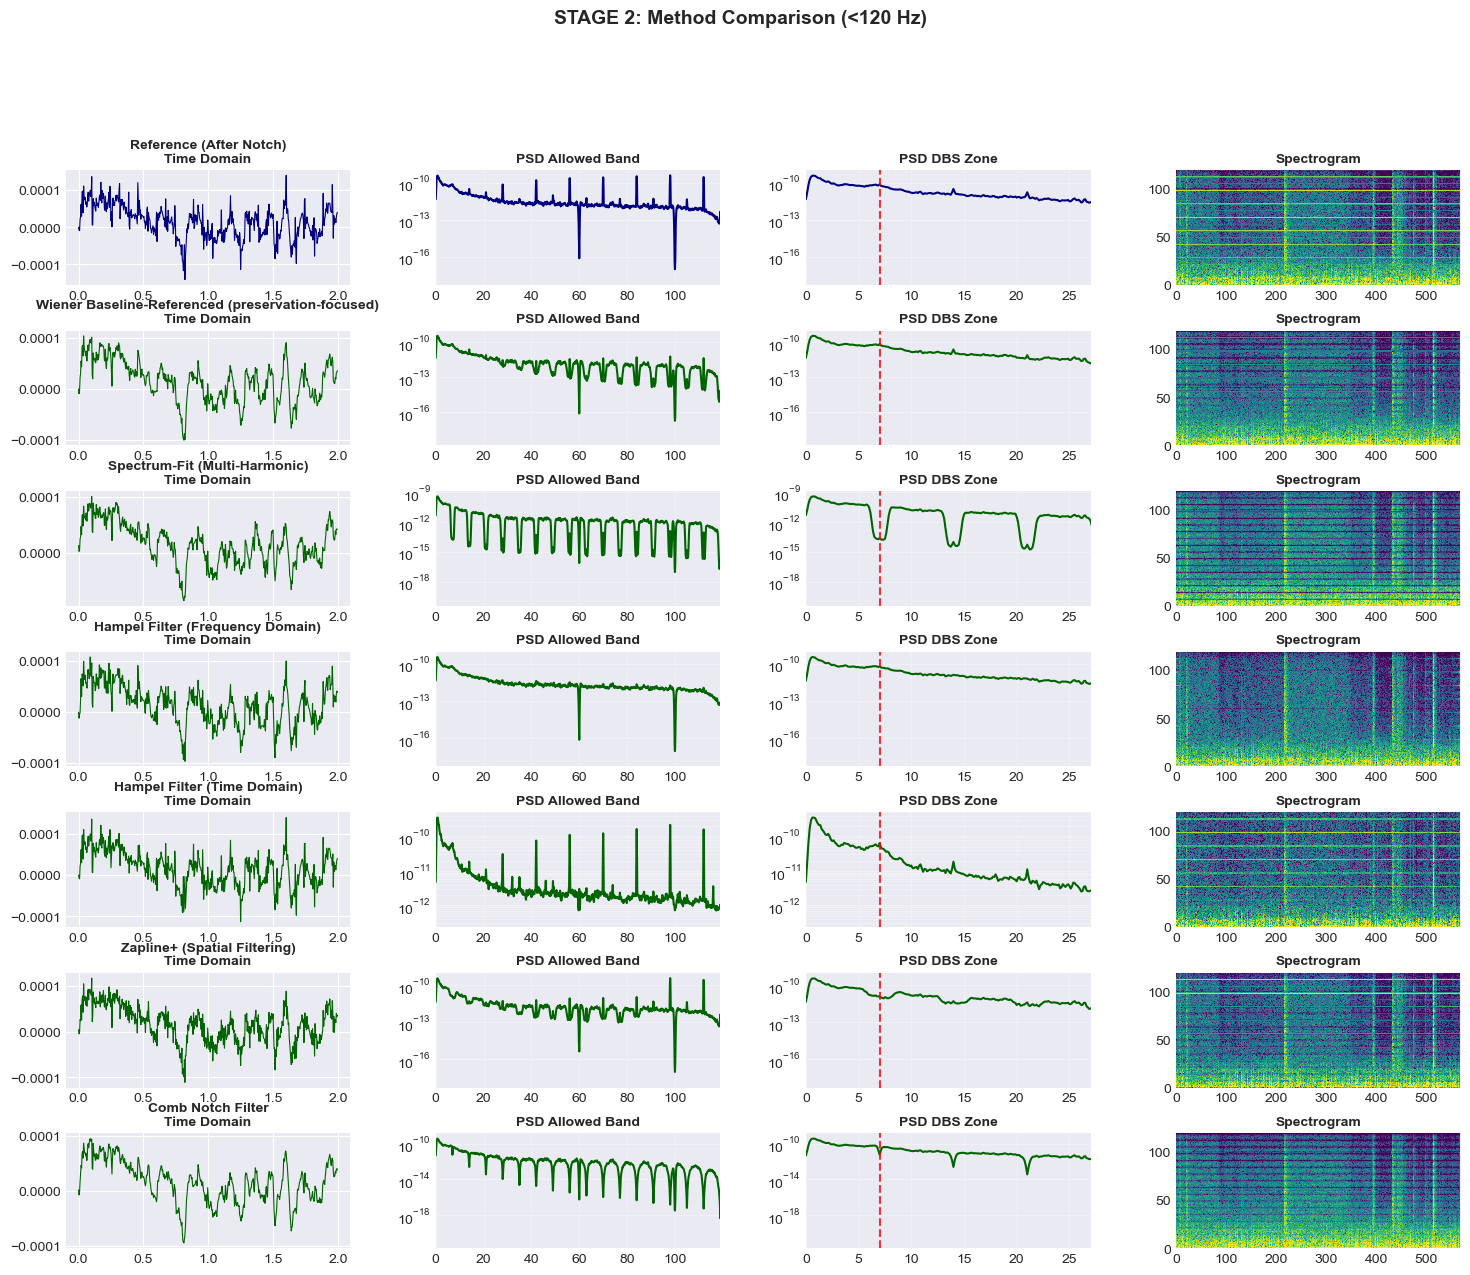

✓ Method comparison complete


In [14]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(len(filtered_results) + 1, 4, figure=fig, hspace=0.4, wspace=0.3)

data_ref = raw_notch.get_data()[0]
freqs_ref, pxx_ref = signal.welch(data_ref, fs=sfreq, nperseg=min(2048, len(data_ref)), window='hann')

def draw_row(ax_t, ax_p, ax_z, ax_s, data_sig, time_sig, title_prefix, color='navy'):
    t_crop = 2.0
    crop_idx = int(t_crop * sfreq)
    ax_t.plot(time_sig[:crop_idx], data_sig[:crop_idx], linewidth=0.8, color=color)
    ax_t.set_title(f'{title_prefix}\nTime Domain', fontsize=10, fontweight='bold')

    freqs_l, pxx_l = signal.welch(data_sig, fs=sfreq, nperseg=min(2048, len(data_sig)), window='hann')
    ax_p.semilogy(freqs_l, pxx_l, linewidth=1.5, color=color)
    ax_p.set_xlim([0, analysis_fmax])
    ax_p.set_title('PSD Allowed Band', fontsize=10, fontweight='bold')
    ax_p.grid(True, alpha=0.3, which='both')

    ax_z.semilogy(freqs_l, pxx_l, linewidth=1.5, color=color)
    ax_z.set_xlim([max(0, dbs_target_freq - 20), min(analysis_fmax, dbs_target_freq + 20)])
    ax_z.axvline(dbs_target_freq, color='red', linestyle='--', alpha=0.8, linewidth=1.5)
    ax_z.set_title('PSD DBS Zone', fontsize=10, fontweight='bold')
    ax_z.grid(True, alpha=0.3, which='both')

    f_sg, t_sg, Sxx = signal.spectrogram(
        data_sig,
        fs=sfreq,
        window='hann',
        nperseg=512,
        noverlap=256,
        nfft=1024,
        detrend=False,
        scaling='density',
        mode='psd'
    )

    band_mask = f_sg <= analysis_fmax
    Sxx_db = 10 * np.log10(Sxx[band_mask] + 1e-20)

    # Auto contrast per panel (more robust than fixed -60..20 dB)
    vmin = np.nanpercentile(Sxx_db, 5)
    vmax = np.nanpercentile(Sxx_db, 99)
    if vmax - vmin < 10:  # avoid near-flat contrast
        vmax = vmin + 10

    ax_s.pcolormesh(
        t_sg, f_sg[band_mask], Sxx_db,
        shading='auto',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )
    ax_s.set_ylim([0, analysis_fmax])
    ax_s.set_xlim([time_sig[0], time_sig[-1]])
    ax_s.set_title('Spectrogram', fontsize=10, fontweight='bold')

draw_row(
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[0, 3]),
    data_ref,
    raw_notch.times,
    'Reference (After Notch)',
    color='navy'
)

for row_idx, (method_name, raw_filtered) in enumerate(filtered_results.items(), start=1):
    method_desc = filter_methods[method_name]['description']
    if raw_filtered is None:
        ax = fig.add_subplot(gs[row_idx, :])
        ax.text(0.5, 0.5, f'FAILED: {method_desc}', ha='center', va='center', color='red', fontsize=12, fontweight='bold', transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    draw_row(
        fig.add_subplot(gs[row_idx, 0]),
        fig.add_subplot(gs[row_idx, 1]),
        fig.add_subplot(gs[row_idx, 2]),
        fig.add_subplot(gs[row_idx, 3]),
        raw_filtered.get_data()[0],
        raw_filtered.times,
        method_desc,
        color='darkgreen'
    )

plt.suptitle('STAGE 2: Method Comparison (<120 Hz)', fontsize=14, fontweight='bold', y=0.995)
plt.show()
print('✓ Method comparison complete')

## 8. Analyze DBS Artifact Attenuation

In [15]:
def harmonic_targets(f0, fmax, n_max=12):
    hs = []
    k = 1
    while (k * f0 < fmax) and (len(hs) < n_max):
        hs.append(round(k * f0, 2))
        k += 1
    return hs

target_freqs = harmonic_targets(dbs_target_freq, analysis_fmax, n_max=12)

print('\n' + '=' * 96)
print('ATTENUATION + PRESERVATION METRICS (7 Hz DBS, <120 Hz constraint)')
print('=' * 96)
print(f'DBS target: {dbs_target_freq:.2f} Hz | harmonic targets: {target_freqs}')

atten_summary = {}
for method_name, raw_filtered in filtered_results.items():
    if raw_filtered is None:
        print(f"- {filter_methods[method_name]['description']}: FAILED")
        continue

    data_filtered = raw_filtered.get_data()[0]
    freqs_filt, pxx_filt = signal.welch(data_filtered, fs=sfreq, nperseg=min(2048, len(data_filtered)), window='hann')

    # Harmonic suppression: power-ratio dB (negative is suppression)
    vals = {}
    for hz in target_freqs:
        idx = int(np.argmin(np.abs(freqs_filt - hz)))
        vals[hz] = float(10 * np.log10((pxx_filt[idx] + 1e-30) / (pxx_ref[idx] + 1e-30)))

    # Off-harmonic preservation: small absolute drift is better
    preserve_mask = (freqs_filt >= 1.0) & (freqs_filt <= min(45.0, analysis_fmax))
    for hz in target_freqs:
        preserve_mask &= np.abs(freqs_filt - hz) > 1.0
    drift_db = 10 * np.log10((pxx_filt[preserve_mask] + 1e-30) / (pxx_ref[preserve_mask] + 1e-30))
    preservation_drift = float(np.mean(np.abs(drift_db))) if np.any(preserve_mask) else np.nan

    mean_harmonic = float(np.mean(list(vals.values())))
    atten_summary[method_name] = {
        'harmonics': vals,
        'mean_harmonic_db': mean_harmonic,
        'preservation_drift_db': preservation_drift
    }

    sample_pairs = list(vals.items())[:6]
    vals_txt = ', '.join([f'{h:.0f}Hz:{v:.2f}dB' for h, v in sample_pairs])
    print(f"- {filter_methods[method_name]['description']}")
    print(f"  harmonic suppression (sample): {vals_txt}")
    print(f"  mean harmonic suppression: {mean_harmonic:.2f} dB | off-harmonic drift: {preservation_drift:.2f} dB")

print('=' * 96)
print('Interpretation: more negative mean harmonic dB is better suppression; lower drift dB is better preservation.')


ATTENUATION + PRESERVATION METRICS (7 Hz DBS, <120 Hz constraint)
DBS target: 7.00 Hz | harmonic targets: [7.0, 14.0, 21.0, 28.0, 35.0, 42.0, 49.0, 56.0, 63.0, 70.0, 77.0, 84.0]
- Wiener Baseline-Referenced (preservation-focused)
  harmonic suppression (sample): 7Hz:-0.06dB, 14Hz:-0.97dB, 21Hz:-3.16dB, 28Hz:-13.72dB, 35Hz:-7.93dB, 42Hz:-17.91dB
  mean harmonic suppression: -12.24 dB | off-harmonic drift: 0.24 dB
- Spectrum-Fit (Multi-Harmonic)
  harmonic suppression (sample): 7Hz:-34.97dB, 14Hz:-35.00dB, 21Hz:-35.00dB, 28Hz:-35.00dB, 35Hz:-35.00dB, 42Hz:-35.00dB
  mean harmonic suppression: -35.00 dB | off-harmonic drift: 0.03 dB
- Hampel Filter (Frequency Domain)
  harmonic suppression (sample): 7Hz:-0.89dB, 14Hz:-3.81dB, 21Hz:-4.24dB, 28Hz:-11.89dB, 35Hz:-1.59dB, 42Hz:-15.74dB
  mean harmonic suppression: -9.70 dB | off-harmonic drift: 0.13 dB
- Hampel Filter (Time Domain)
  harmonic suppression (sample): 7Hz:-0.54dB, 14Hz:-2.13dB, 21Hz:-1.65dB, 28Hz:-3.50dB, 35Hz:1.44dB, 42Hz:-3.03

## 9. Before/After Side-by-Side Comparison

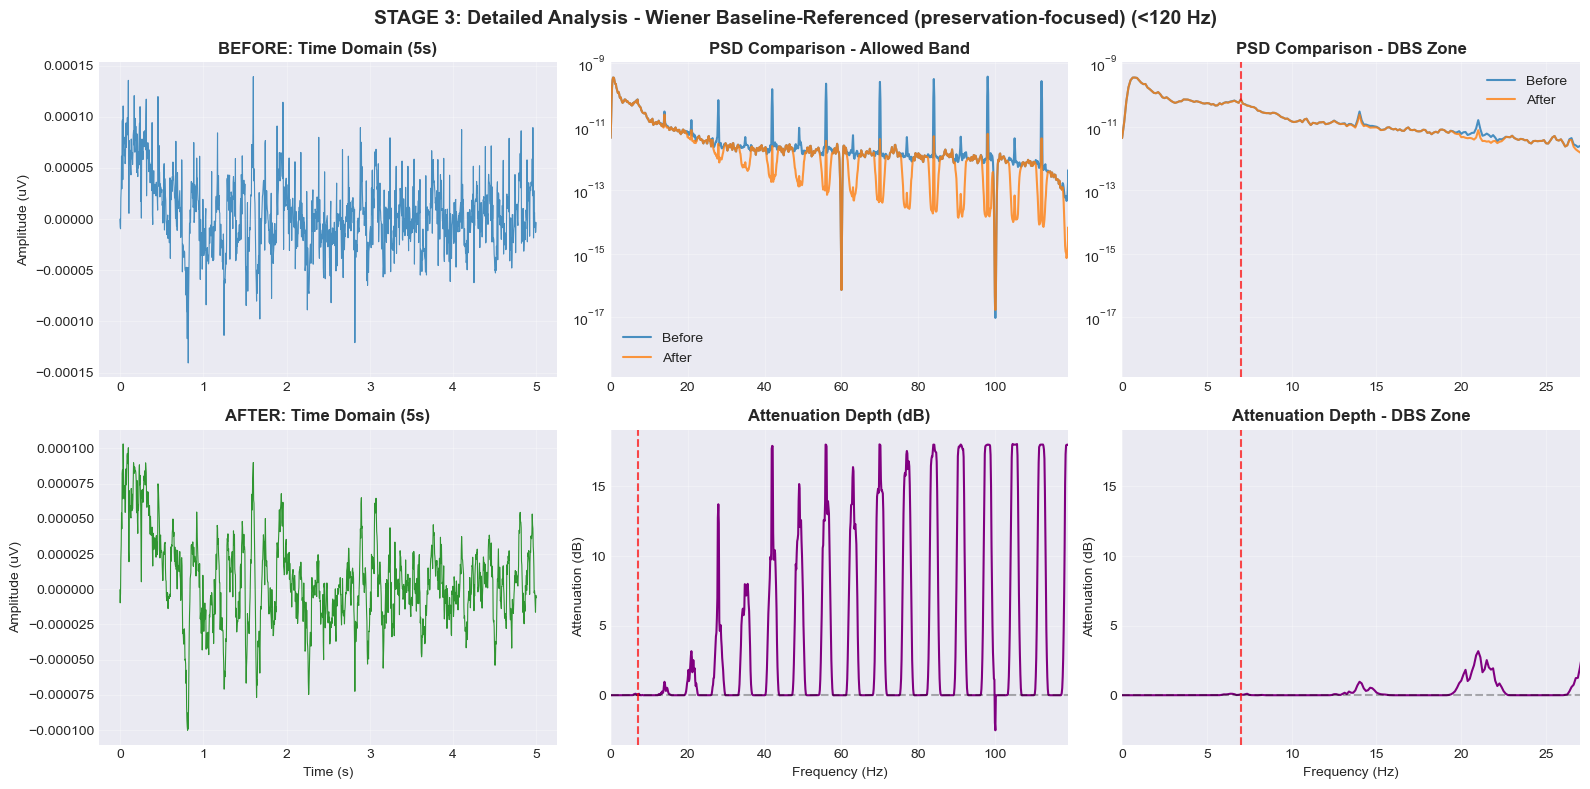

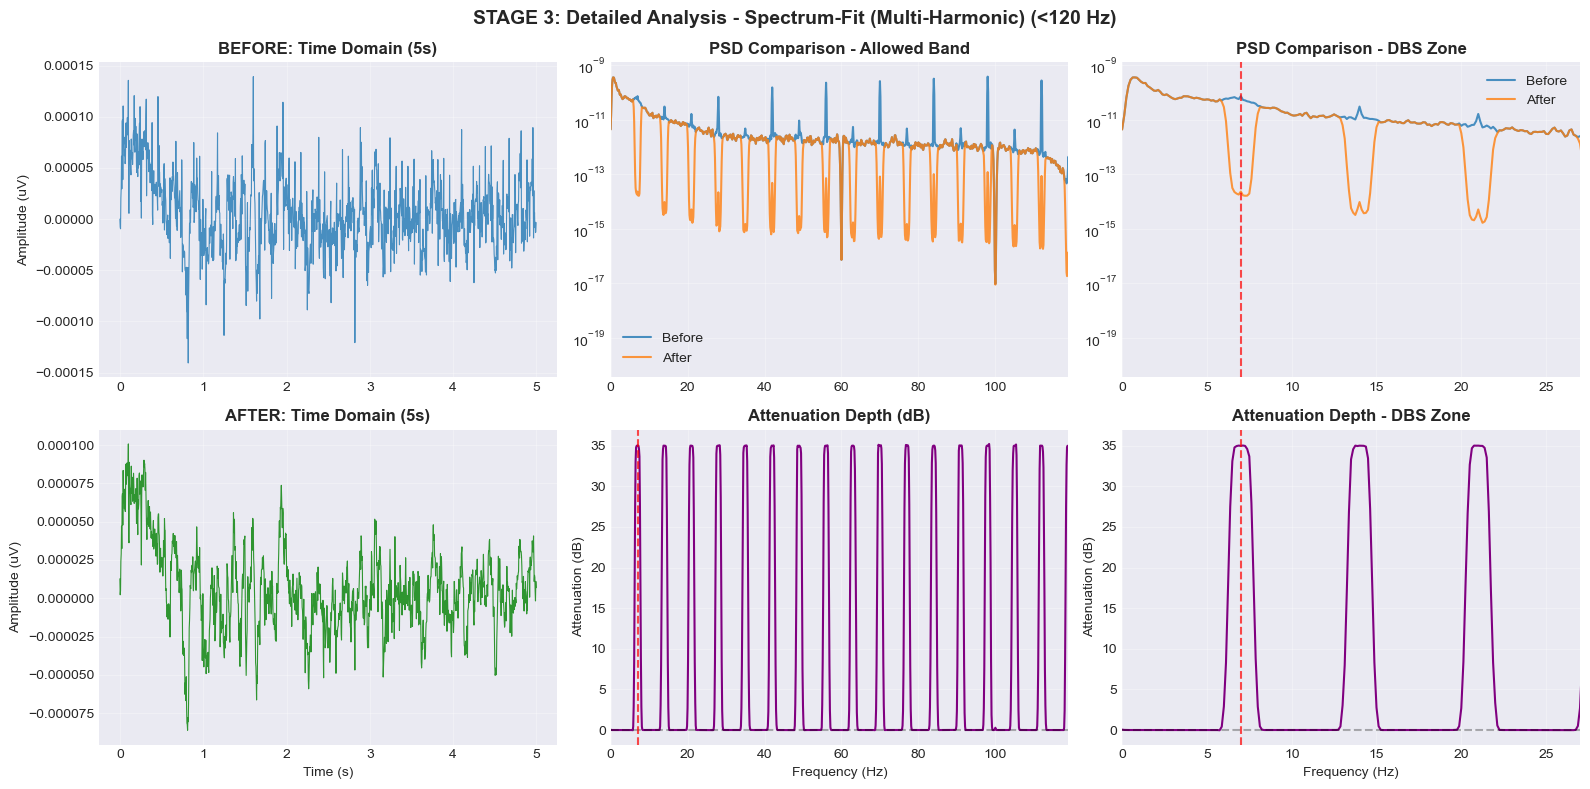

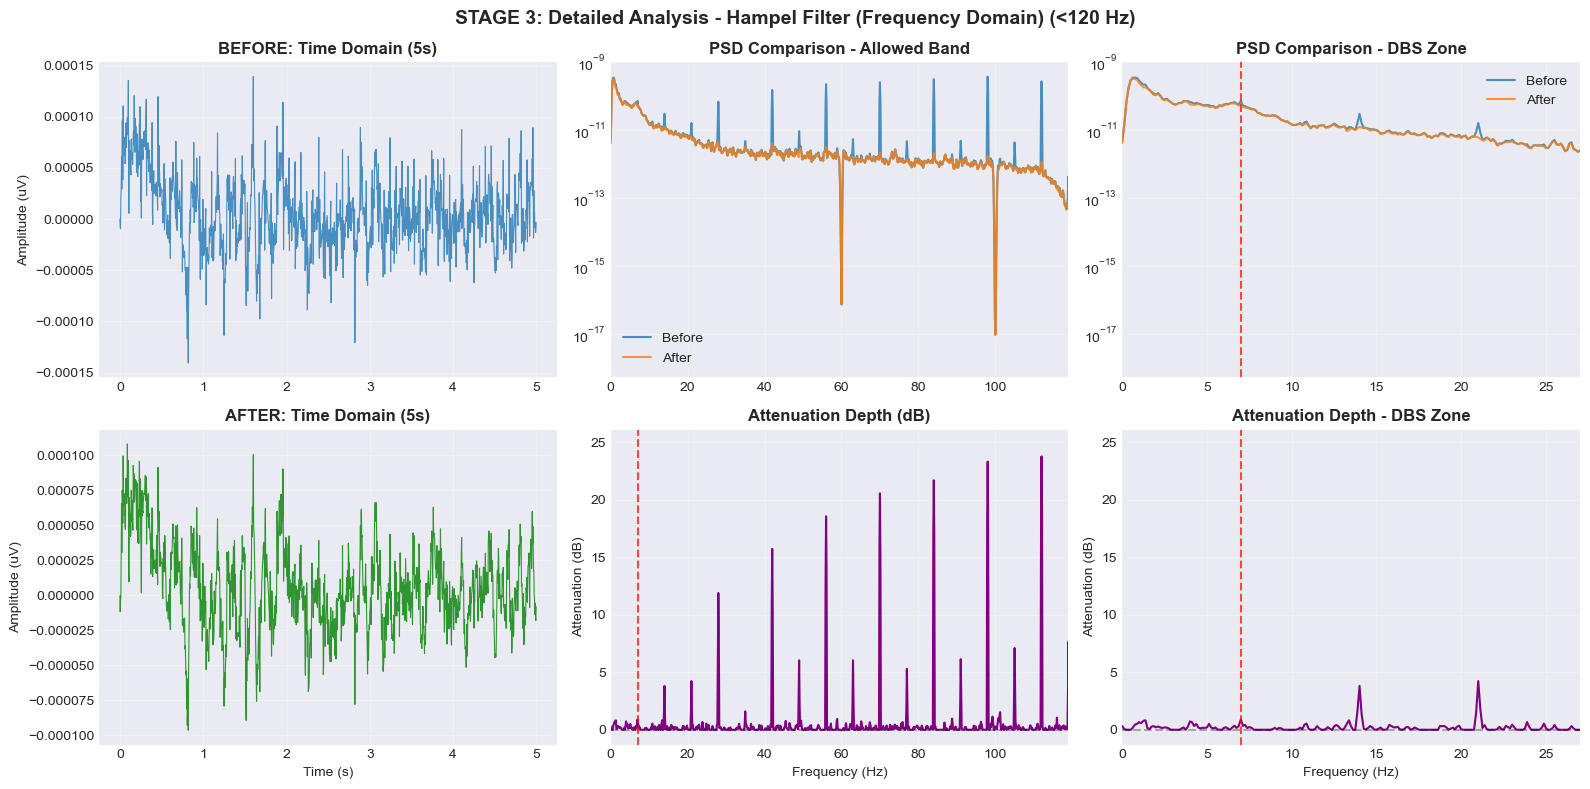

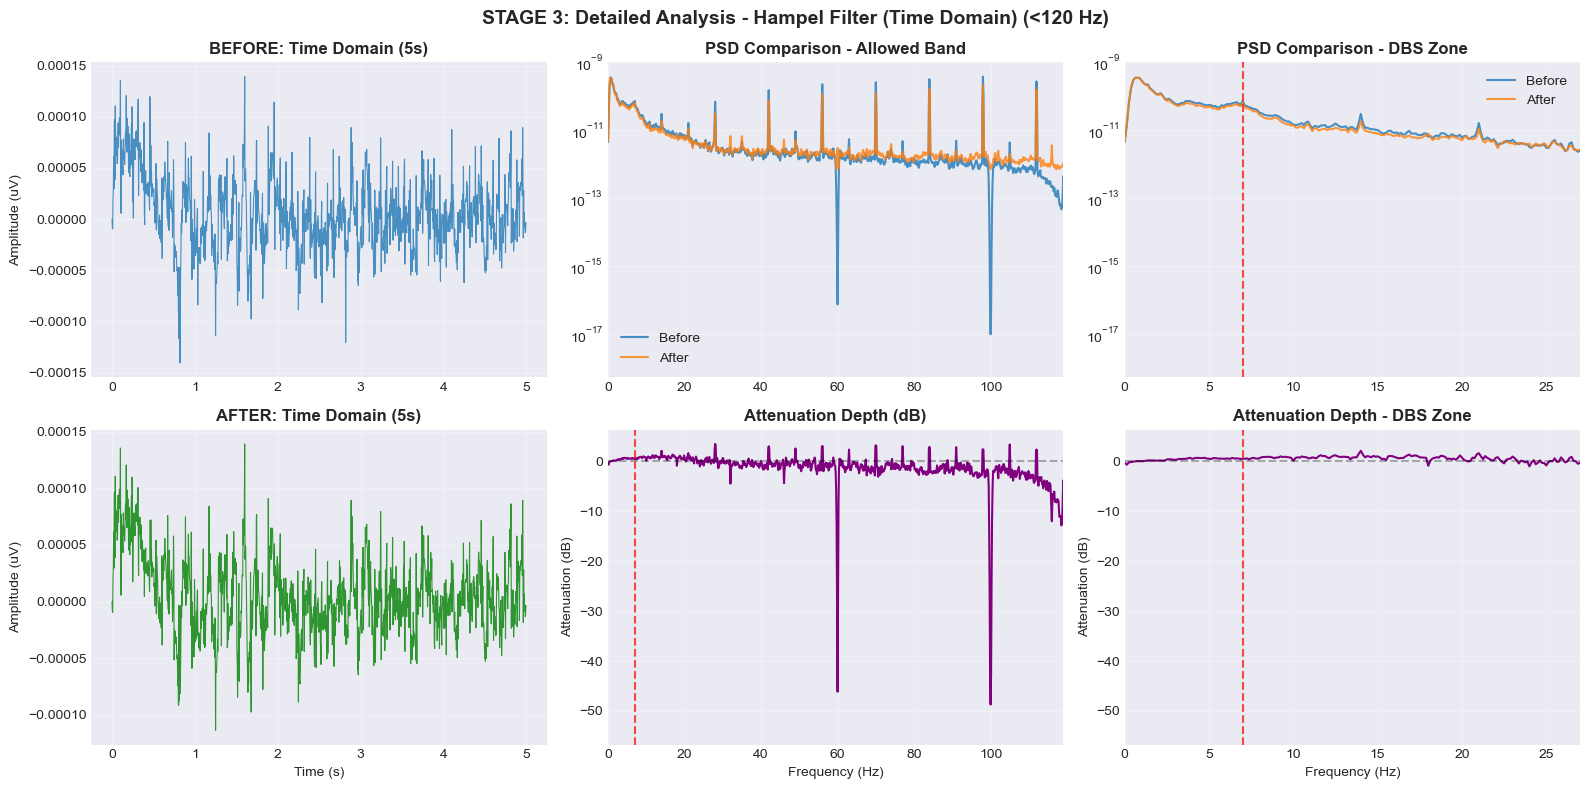

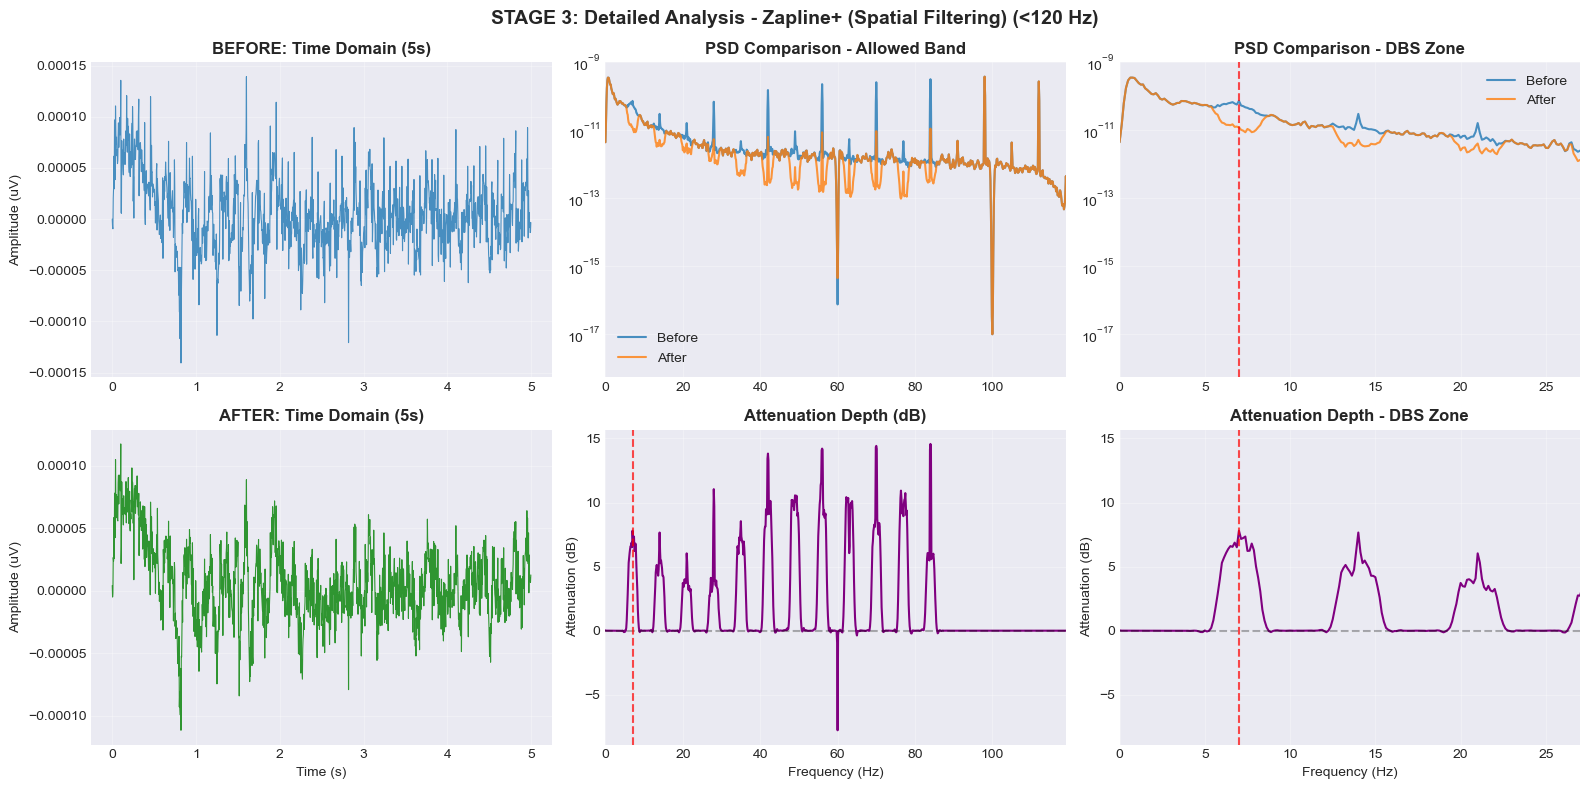

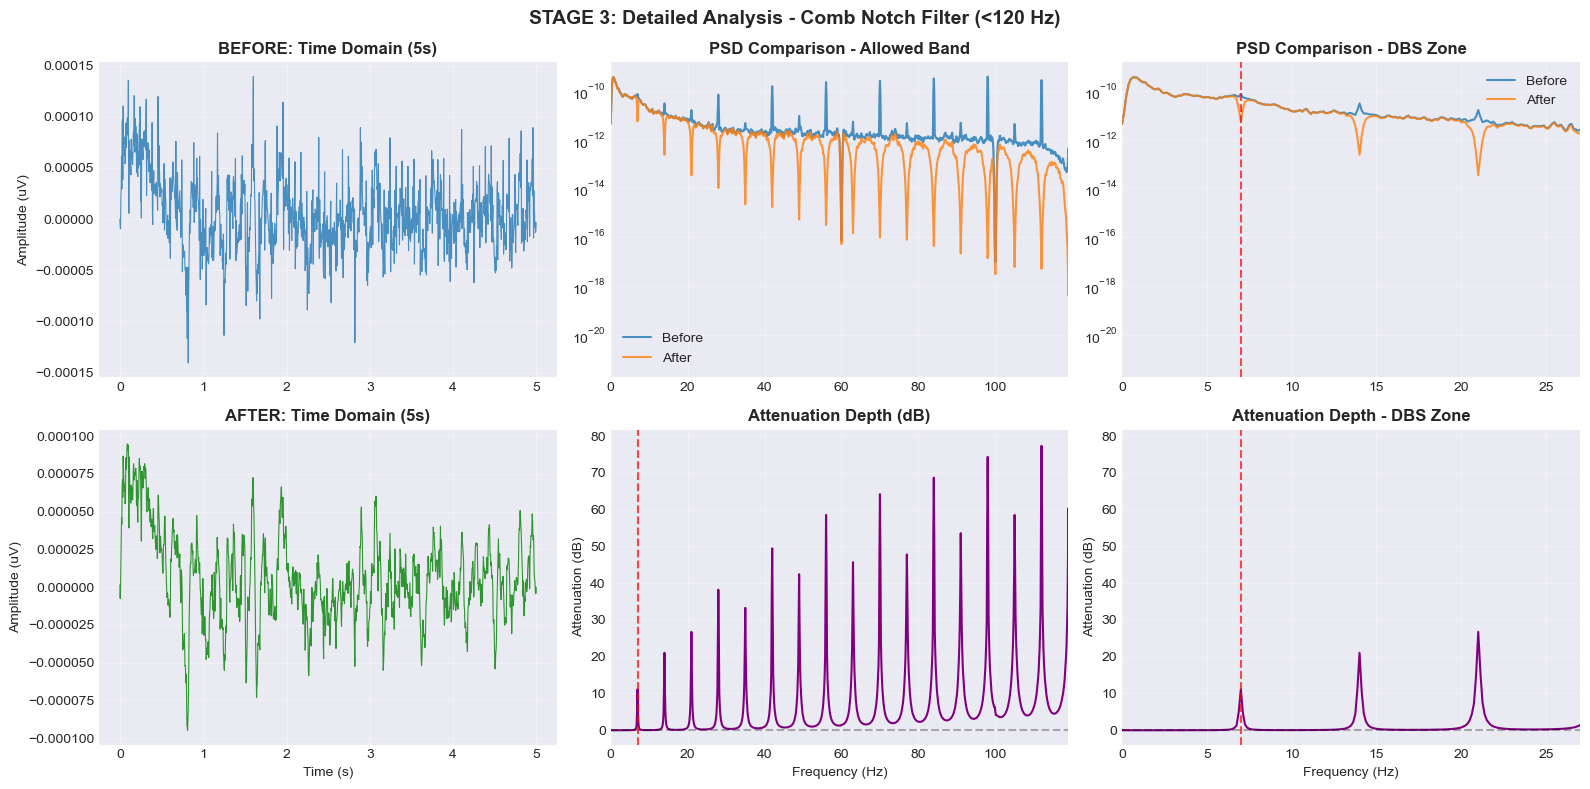


✓ Detailed comparisons generated for 6 methods


In [9]:
successful_filters = {k: v for k, v in filtered_results.items() if v is not None}

for method_name, raw_filtered in successful_filters.items():
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    data_before = raw_notch.get_data()[0]
    data_after = raw_filtered.get_data()[0]

    t_crop = 5
    crop_idx = int(t_crop * sfreq)

    axes[0, 0].plot(raw_notch.times[:crop_idx], data_before[:crop_idx], linewidth=0.8, alpha=0.8)
    axes[0, 0].set_title('BEFORE: Time Domain (5s)', fontweight='bold')
    axes[0, 0].set_ylabel('Amplitude (uV)')
    axes[0, 0].grid(True, alpha=0.3)

    axes[1, 0].plot(raw_filtered.times[:crop_idx], data_after[:crop_idx], linewidth=0.8, alpha=0.8, color='green')
    axes[1, 0].set_title('AFTER: Time Domain (5s)', fontweight='bold')
    axes[1, 0].set_ylabel('Amplitude (uV)')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].grid(True, alpha=0.3)

    freqs_b, pxx_b = signal.welch(data_before, fs=sfreq, nperseg=min(2048, len(data_before)), window='hann')
    freqs_a, pxx_a = signal.welch(data_after, fs=sfreq, nperseg=min(2048, len(data_after)), window='hann')

    axes[0, 1].semilogy(freqs_b, pxx_b, linewidth=1.5, label='Before', alpha=0.8)
    axes[0, 1].semilogy(freqs_a, pxx_a, linewidth=1.5, label='After', alpha=0.8)
    axes[0, 1].set_title('PSD Comparison - Allowed Band', fontweight='bold')
    axes[0, 1].set_xlim([0, analysis_fmax])
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, which='both')

    pxx_diff = 10 * np.log10((pxx_b + 1e-30) / (pxx_a + 1e-30))
    axes[1, 1].plot(freqs_b, pxx_diff, linewidth=1.5, color='purple')
    axes[1, 1].set_title('Attenuation Depth (dB)', fontweight='bold')
    axes[1, 1].set_xlim([0, analysis_fmax])
    axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[1, 1].axvline(x=dbs_target_freq, color='red', linestyle='--', alpha=0.7)
    axes[1, 1].set_ylabel('Attenuation (dB)')
    axes[1, 1].set_xlabel('Frequency (Hz)')
    axes[1, 1].grid(True, alpha=0.3)

    axes[0, 2].semilogy(freqs_b, pxx_b, linewidth=1.5, label='Before', alpha=0.8)
    axes[0, 2].semilogy(freqs_a, pxx_a, linewidth=1.5, label='After', alpha=0.8)
    axes[0, 2].set_title('PSD Comparison - DBS Zone', fontweight='bold')
    axes[0, 2].set_xlim([max(0, dbs_target_freq - 20), min(analysis_fmax, dbs_target_freq + 20)])
    axes[0, 2].axvline(x=dbs_target_freq, color='red', linestyle='--', alpha=0.7)
    axes[0, 2].grid(True, alpha=0.3, which='both')
    axes[0, 2].legend()

    axes[1, 2].plot(freqs_b, pxx_diff, linewidth=1.5, color='purple')
    axes[1, 2].set_title('Attenuation Depth - DBS Zone', fontweight='bold')
    axes[1, 2].set_xlim([max(0, dbs_target_freq - 20), min(analysis_fmax, dbs_target_freq + 20)])
    axes[1, 2].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[1, 2].axvline(x=dbs_target_freq, color='red', linestyle='--', alpha=0.7)
    axes[1, 2].set_ylabel('Attenuation (dB)')
    axes[1, 2].set_xlabel('Frequency (Hz)')
    axes[1, 2].grid(True, alpha=0.3)

    method_desc = filter_methods[method_name]['description']
    plt.suptitle(f'STAGE 3: Detailed Analysis - {method_desc} (<120 Hz)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f'\n✓ Detailed comparisons generated for {len(successful_filters)} methods')

## 10. Summary & Recommendations

In [10]:
print('\n' + '=' * 96)
print('DIAGNOSTIC SUMMARY (7 Hz DBS, baseline-referenced)')
print('=' * 96)

successful_filters = {k: v for k, v in filtered_results.items() if v is not None}

if not successful_filters:
    print('\nCRITICAL: all methods failed under current configuration.')
    print('Troubleshooting:')
    print('1. Confirm EDF loading and channel intersection between DBS and baseline.')
    print('2. Verify SciPy/MNE environment versions.')
    print('3. Re-run with shorter sample window to isolate failures.')
else:
    print(f'\nDBS file: {test_file.name}')
    print(f'Baseline file: {baseline_file.name}')
    print(f'Sampling rate: {sfreq:.1f} Hz (Nyquist {sfreq/2:.1f} Hz)')
    print(f'Frequency ceiling applied: {analysis_fmax:.1f} Hz')
    print(f'DBS target used: {dbs_target_freq:.2f} Hz')
    print(f'Working methods: {len(successful_filters)}/{len(filter_methods)}')

    for m in successful_filters:
        print(f"- {filter_methods[m]['description']}")

    # 1) Suppression-priority ranking (more negative = stronger)
    suppress_best = min(atten_summary.keys(), key=lambda m: atten_summary[m]['mean_harmonic_db'])

    # 2) Preservation-priority ranking at low harmonics (7/14/21 Hz): closer to 0 dB = better preservation
    def low_harmonics_mean(m):
        hvals = atten_summary[m]['harmonics']
        low = [v for hz, v in hvals.items() if hz <= 21.0]
        return float(np.mean(low)) if low else np.nan

    preserve_best = min(atten_summary.keys(), key=lambda m: abs(low_harmonics_mean(m)))

    sb = atten_summary[suppress_best]
    pb = atten_summary[preserve_best]
    print(f"\nSuppression-priority best: {filter_methods[suppress_best]['description']}")
    print(f"Mean harmonic suppression: {sb['mean_harmonic_db']:.2f} dB | off-harmonic drift: {sb['preservation_drift_db']:.2f} dB")

    print(f"\nPreservation-priority best (7/14/21 Hz): {filter_methods[preserve_best]['description']}")
    print(f"Low-harmonics mean change: {low_harmonics_mean(preserve_best):.2f} dB | off-harmonic drift: {pb['preservation_drift_db']:.2f} dB")

print('\nFor your goal (remove DBS while preserving 7/14/... activity), use the preservation-priority method and then tune alpha/bandwidth gradually.')
print('=' * 96)


DIAGNOSTIC SUMMARY (7 Hz DBS, baseline-referenced)

DBS file: XUAWAKE7_deidentified.edf
Baseline file: XUAWAKEPRE_deidentified.edf
Sampling rate: 256.0 Hz (Nyquist 128.0 Hz)
Frequency ceiling applied: 119.0 Hz
DBS target used: 7.00 Hz
Working methods: 6/6
- Wiener Baseline-Referenced (preservation-focused)
- Spectrum-Fit (Multi-Harmonic)
- Hampel Filter (Frequency Domain)
- Hampel Filter (Time Domain)
- Zapline+ (Spatial Filtering)
- Comb Notch Filter

Suppression-priority best: Comb Notch Filter
Mean harmonic suppression: -42.27 dB | off-harmonic drift: 0.42 dB

Preservation-priority best (7/14/21 Hz): Wiener Baseline-Referenced (preservation-focused)
Low-harmonics mean change: -1.40 dB | off-harmonic drift: 0.24 dB

For your goal (remove DBS while preserving 7/14/... activity), use the preservation-priority method and then tune alpha/bandwidth gradually.


In [11]:
# Tune Wiener baseline-referenced filter for 7 Hz preservation/removal tradeoff
candidates = [1.05, 1.10, 1.20, 1.30, 1.50]
print('alpha | low_harmonics_mean_db (7/14/21) | all_harmonics_mean_db | off_harmonic_drift_db')

best_alpha = None
best_score = None

for alpha in candidates:
    tuned = preprocessor.remove_artifacts_baseline(
        raw_notch.copy(),
        baseline_proc.copy(),
        dbs_freq=float(dbs_target_freq),
        harmonic_bandwidth=1.5,
        n_fft=2048,
        floor_db=-18.0,
        alpha=alpha,
        taper_width=1.0,
    )

    data_t = tuned.get_data()[0]
    f_t, p_t = signal.welch(data_t, fs=sfreq, nperseg=min(2048, len(data_t)), window='hann')

    vals = {}
    for hz in target_freqs:
        idx = int(np.argmin(np.abs(f_t - hz)))
        vals[hz] = float(10 * np.log10((p_t[idx] + 1e-30) / (pxx_ref[idx] + 1e-30)))

    low = [v for hz, v in vals.items() if hz <= 21.0]
    low_mean = float(np.mean(low)) if low else np.nan
    all_mean = float(np.mean(list(vals.values())))

    preserve_mask = (f_t >= 1.0) & (f_t <= min(45.0, analysis_fmax))
    for hz in target_freqs:
        preserve_mask &= np.abs(f_t - hz) > 1.0
    drift = 10 * np.log10((p_t[preserve_mask] + 1e-30) / (pxx_ref[preserve_mask] + 1e-30))
    drift_mean = float(np.mean(np.abs(drift))) if np.any(preserve_mask) else np.nan

    # Preservation-first with some suppression pressure at harmonics
    score = abs(low_mean) + 0.15 * abs(all_mean)
    if (best_score is None) or (score < best_score):
        best_score = score
        best_alpha = alpha

    print(f'{alpha:.2f} | {low_mean:.2f} | {all_mean:.2f} | {drift_mean:.2f}')

print(f'\nSuggested alpha for preservation-first Wiener setup: {best_alpha:.2f}')

alpha | low_harmonics_mean_db (7/14/21) | all_harmonics_mean_db | off_harmonic_drift_db
Baseline-Referenced Wiener Filter: f0=7.0 Hz, bandwidth=1.5 Hz (+1.0 Hz taper), alpha=1.05, n_fft=2048
     7.0 Hz: median attenuation = +0.0 dB
    14.0 Hz: median attenuation = -0.0 dB
    21.0 Hz: median attenuation = -0.1 dB
    28.0 Hz: median attenuation = -1.4 dB
    35.0 Hz: median attenuation = -0.4 dB
    42.0 Hz: median attenuation = -2.0 dB
    49.0 Hz: median attenuation = -1.7 dB
    56.0 Hz: median attenuation = -2.1 dB
    63.0 Hz: median attenuation = -2.1 dB
    70.0 Hz: median attenuation = -2.7 dB
1.05 | -1.15 | -11.79 | 0.22
Baseline-Referenced Wiener Filter: f0=7.0 Hz, bandwidth=1.5 Hz (+1.0 Hz taper), alpha=1.1, n_fft=2048
     7.0 Hz: median attenuation = +0.0 dB
    14.0 Hz: median attenuation = -0.0 dB
    21.0 Hz: median attenuation = -0.1 dB
    28.0 Hz: median attenuation = -1.4 dB
    35.0 Hz: median attenuation = -0.4 dB
    42.0 Hz: median attenuation = -2.0 dB
    49

# Synthetic Validation of DBS Filter Methods

## Generating signal

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import mne
from copy import deepcopy

In [77]:
fs = 250.0
duration = 10.0
t = np.arange(0, duration, 1/fs)
f_dbs = 7.0
f_alpha = 10.0
ch_names = ['Fp1', 'Fp2', 'F3']

In [78]:
# Generate Brain Ground Truth (1/f + Alpha)
b, a = signal.butter(1, 0.5, btype='low', fs=fs)
brain_source = signal.lfilter(b, a, np.random.randn(len(t)))
alpha_rhythm = 0.6 * np.sin(2 * np.pi * f_alpha * t)
s_true = brain_source + alpha_rhythm

In [79]:
# Generate DBS Artifact (7Hz Square Wave)
a_dbs = 2.5 * signal.square(2 * np.pi * f_dbs * t, duty=0.1)

In [80]:
# Spatial Mixing Matrix (Channel-specific noise levels)
# [Brain Weight, Artifact Weight]
mixing = np.array([
    [1.0, 1.0],  # Fp1: Standard
    [0.7, 2.2],  # Fp2: Saturated by DBS
    [1.2, 0.3]   # F3: Mostly Clean Brain
])

data_raw = mixing @ np.vstack([s_true, a_dbs])
data_true = mixing[:, 0:1] @ s_true.reshape(1, -1)

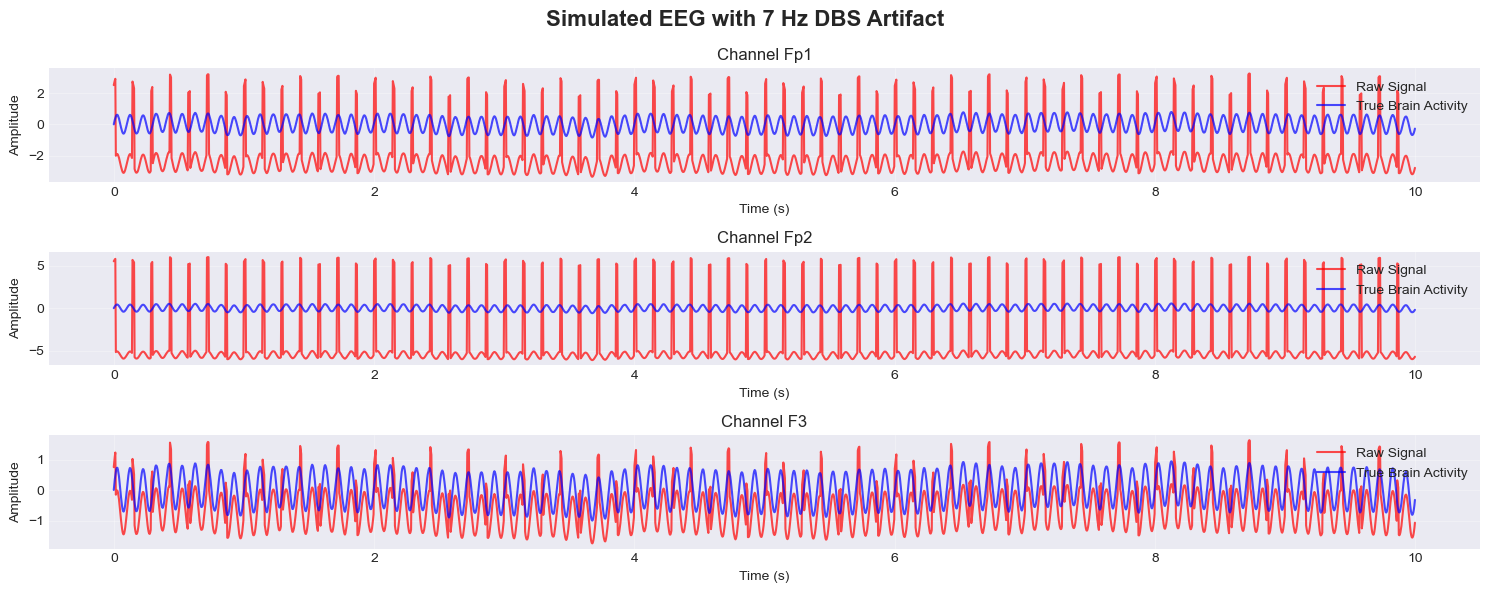

In [81]:
# plot data_raw and data_true for visual comparison
plt.figure(figsize=(15, 6))
for i in range(len(ch_names)):
    plt.subplot(len(ch_names), 1, i+1)
    plt.plot(t, data_raw[i], label='Raw Signal', color='red', alpha=0.7)
    plt.plot(t, data_true[i], label='True Brain Activity', color='blue', alpha=0.7)
    plt.title(f'Channel {ch_names[i]}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.suptitle('Simulated EEG with 7 Hz DBS Artifact', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [82]:
# Create MNE Objects
info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=['eeg']*3)
raw_mne = mne.io.RawArray(data_raw, info, verbose='ERROR')
true_mne = mne.io.RawArray(data_true, info.copy(), verbose='ERROR')

In [88]:
# ==========================================
# 2. METRICS & PLOTTING ENGINE
# ==========================================
def run_advanced_validation(method_name, config, raw_obj, true_obj):
    description = config['description']
    print(f"Validating: {description}...")

    # --- Filtering Execution ---
    raw_to_filter = raw_obj.copy().load_data()
    data = raw_to_filter.get_data()
    
    # Special handling for Wiener which requires a baseline MNE object
    if method_name == 'wiener_baseline':
        # In this synthetic test, we use ground truth as the ideal baseline
        # and route through the baseline-referenced preprocessor API.
        preproc_tmp = EEGPreprocessor(generate_plots=False)
        params = dict(config['params'])
        dbs_freq = float(params.pop('dbs_freq', 7.0))
        cleaned_raw = preproc_tmp.remove_artifacts_baseline(
            raw_to_filter,
            true_obj.copy().load_data(),
            dbs_freq=dbs_freq,
            **params
        )
        cleaned_data = cleaned_raw.get_data()
    else:
        cleaned_data = ArtifactFilterFactory.process(
            method=method_name, data=data, sfreq=fs, **config['params']
        )

    # --- Metric Calculation (Channel 0)
    sig_p = np.mean(data_true[0]**2)
    noise_init = np.mean((data_raw[0] - data_true[0])**2)
    noise_final = np.mean((cleaned_data[0] - data_true[0])**2)
    snr_gain = 10*np.log10(sig_p/noise_final) - 10*np.log10(sig_p/noise_init)

    # --- Advanced Visualization ---
    fig = plt.figure(figsize=(22, 12))
    fig.suptitle(f"VALIDATION: {description}\nSNR Gain: {snr_gain:.2f} dB", fontsize=16, fontweight='bold')
    gs = fig.add_gridspec(3, 4)

    # 1. Time Domain Comparison
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.plot(t[:500], data_raw[0, :500], 'r', alpha=0.3, label='Raw (Brain+DBS)')
    ax1.plot(t[:500], data_true[0, :500], 'k', linewidth=1.2, label='True Brain')
    ax1.plot(t[:500], cleaned_data[0, :500], 'b', alpha=0.8, label='Cleaned')
    ax1.set_title("Time Domain (Zoom: First 2s)")
    ax1.legend(loc='upper right')

    # 2. PSD Comparison (Allowed Band vs DBS Zone)
    f, p_raw = signal.welch(data_raw[0], fs, nperseg=int(fs*2))
    _, p_filt = signal.welch(cleaned_data[0], fs, nperseg=int(fs*2))
    _, p_true = signal.welch(data_true[0], fs, nperseg=int(fs*2))

    ax2 = fig.add_subplot(gs[1, 0:2])
    ax2.semilogy(f, p_raw, 'r', alpha=0.2, label='Raw')
    ax2.semilogy(f, p_true, 'k', alpha=0.5, label='Truth')
    ax2.semilogy(f, p_filt, 'b', label='Cleaned')
    ax2.set_title("PSD: Allowed Band (Full Spectrum)")
    ax2.set_xlim([0, fs/2])

    ax3 = fig.add_subplot(gs[1, 2:])
    ax3.semilogy(f, p_raw, 'r', alpha=0.2)
    ax3.semilogy(f, p_true, 'k', alpha=0.8)
    ax3.semilogy(f, p_filt, 'b')
    ax3.axvline(7, color='green', linestyle='--', label='DBS (7Hz)')
    ax3.axvline(10, color='orange', linestyle='--', label='Alpha (10Hz)')
    ax3.set_xlim([4, 15])
    ax3.set_title("PSD Zoom: DBS Zone vs. Neural Preservation")
    ax3.legend()

    # 3. Spectrogram (Temporal Stability)
    ax4 = fig.add_subplot(gs[0, 2])
    freqs, times, Sxx = signal.spectrogram(data_raw[0], fs)
    ax4.pcolormesh(times, freqs, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis')
    ax4.set_title("Spectrogram (Raw)")
    ax4.set_ylim([0, 60])

    ax5 = fig.add_subplot(gs[0, 3])
    freqs, times, Sxx_f = signal.spectrogram(cleaned_data[0], fs)
    ax5.pcolormesh(times, freqs, 10 * np.log10(Sxx_f), shading='gouraud', cmap='viridis')
    ax5.set_title("Spectrogram (Cleaned)")
    ax5.set_ylim([0, 60])

    # 4. Multi-Channel Error Heatmap (Spatial Check)
    ax6 = fig.add_subplot(gs[2, :])
    abs_error = np.abs(cleaned_data - data_true)
    im = ax6.imshow(abs_error, aspect='auto', cmap='Reds', extent=[0, duration, 3, 0])
    ax6.set_yticks([0.5, 1.5, 2.5])
    ax6.set_yticklabels(ch_names)
    ax6.set_title("Spatial Integrity: Absolute Error vs Ground Truth Across Channels")
    plt.colorbar(im, ax=ax6, label="Error Magnitude")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Validating: Wiener Baseline-Referenced (preservation-focused)...
Baseline-Referenced Wiener Filter: f0=7.0 Hz, bandwidth=1.5 Hz (+1.0 Hz taper), alpha=1.5, n_fft=2048
     7.0 Hz: median attenuation = -5.2 dB
    14.0 Hz: median attenuation = -10.9 dB
    21.0 Hz: median attenuation = -8.3 dB
    28.0 Hz: median attenuation = -8.5 dB
    35.0 Hz: median attenuation = -9.5 dB
    42.0 Hz: median attenuation = -10.4 dB
    49.0 Hz: median attenuation = -10.4 dB
    56.0 Hz: median attenuation = -11.2 dB
    63.0 Hz: median attenuation = -9.6 dB
    70.0 Hz: median attenuation = -3.6 dB


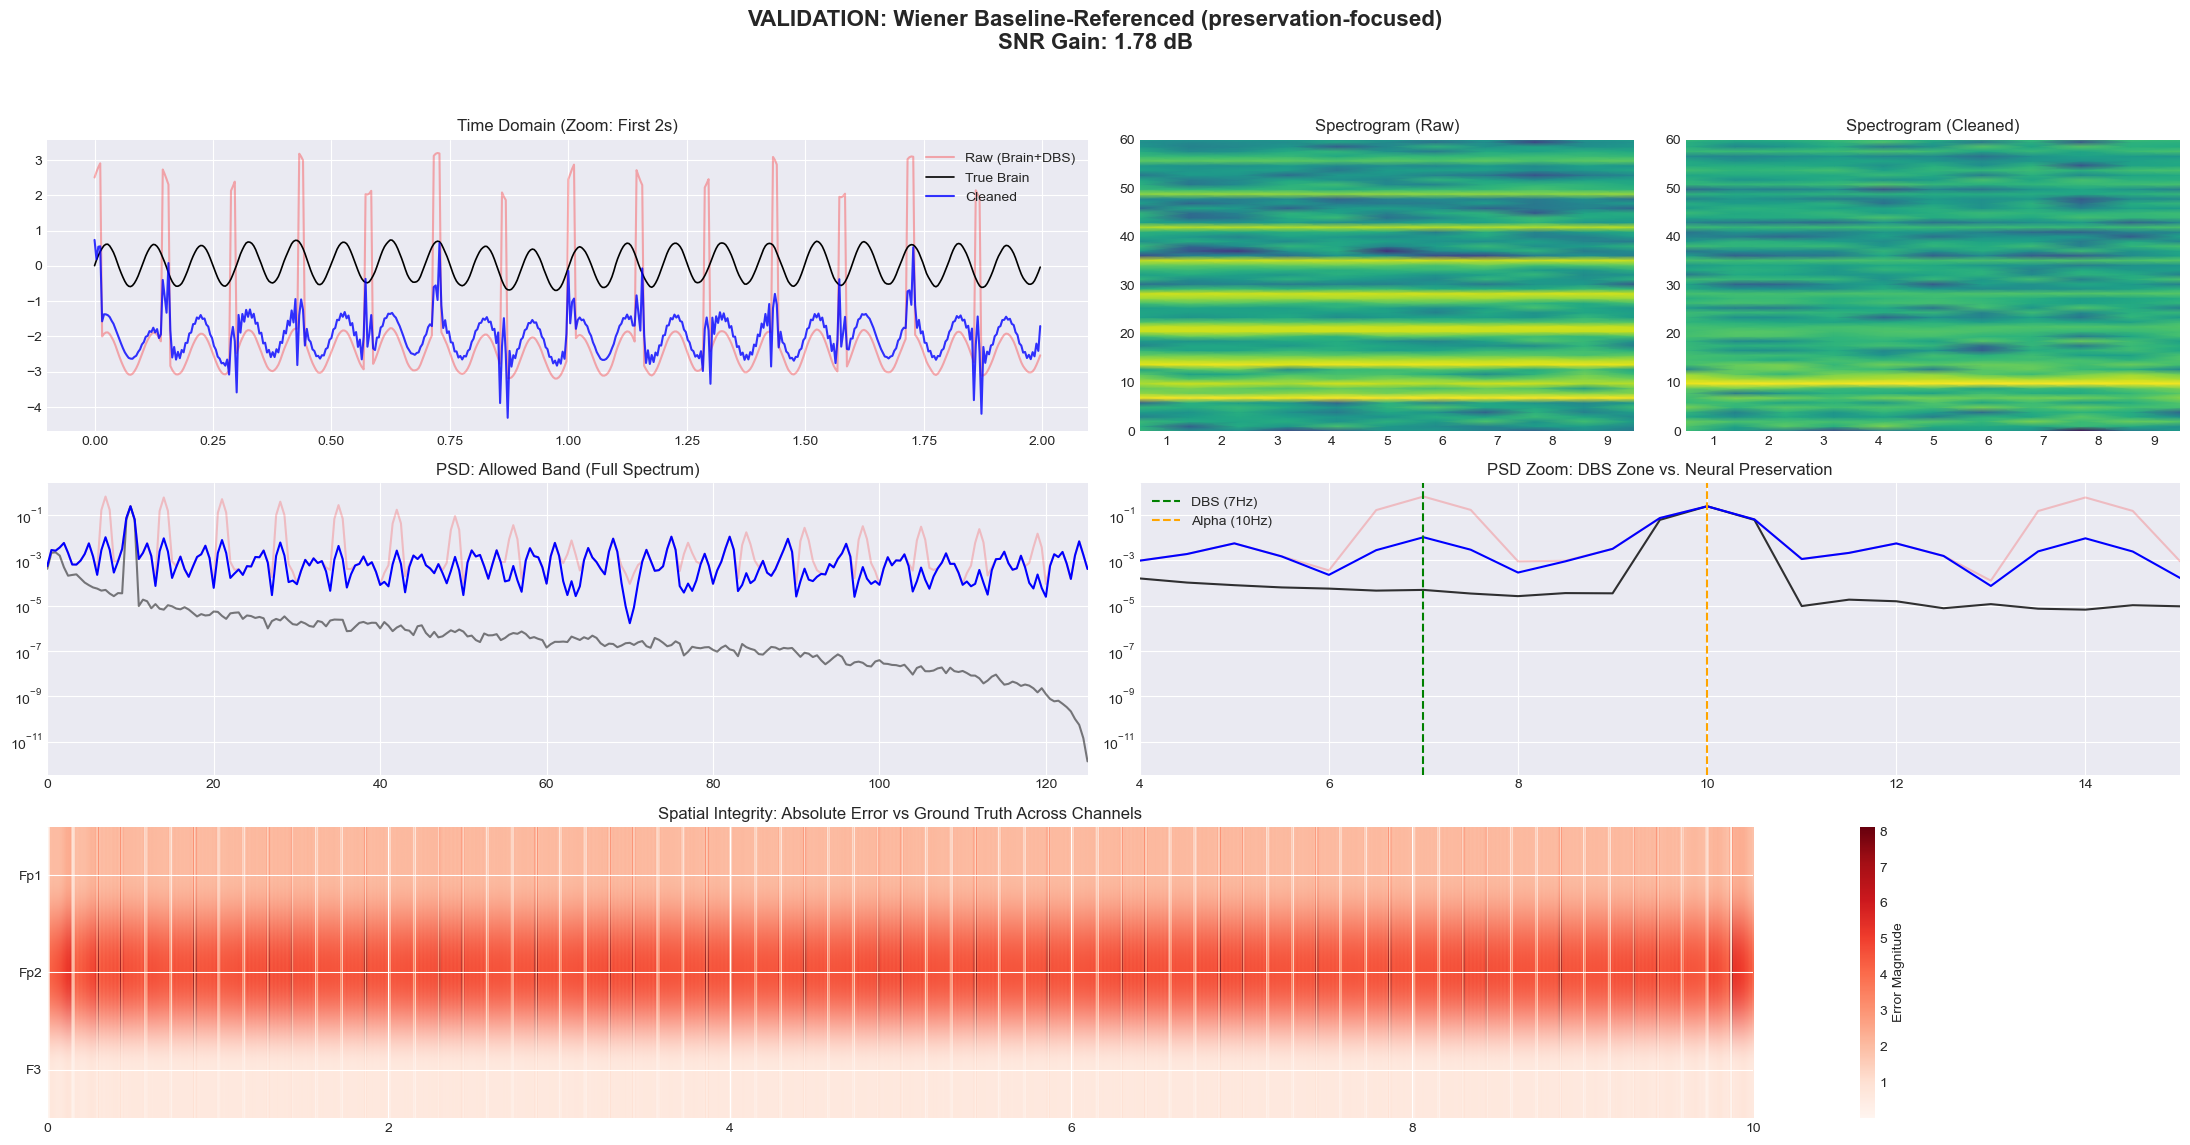

Validating: Spectrum-Fit (Multi-Harmonic)...
Applying Spectrum-Fit Multi-Harmonic Removal (f=7.0Hz, bandwidth=1.5Hz, attenuation=-35.0dB)


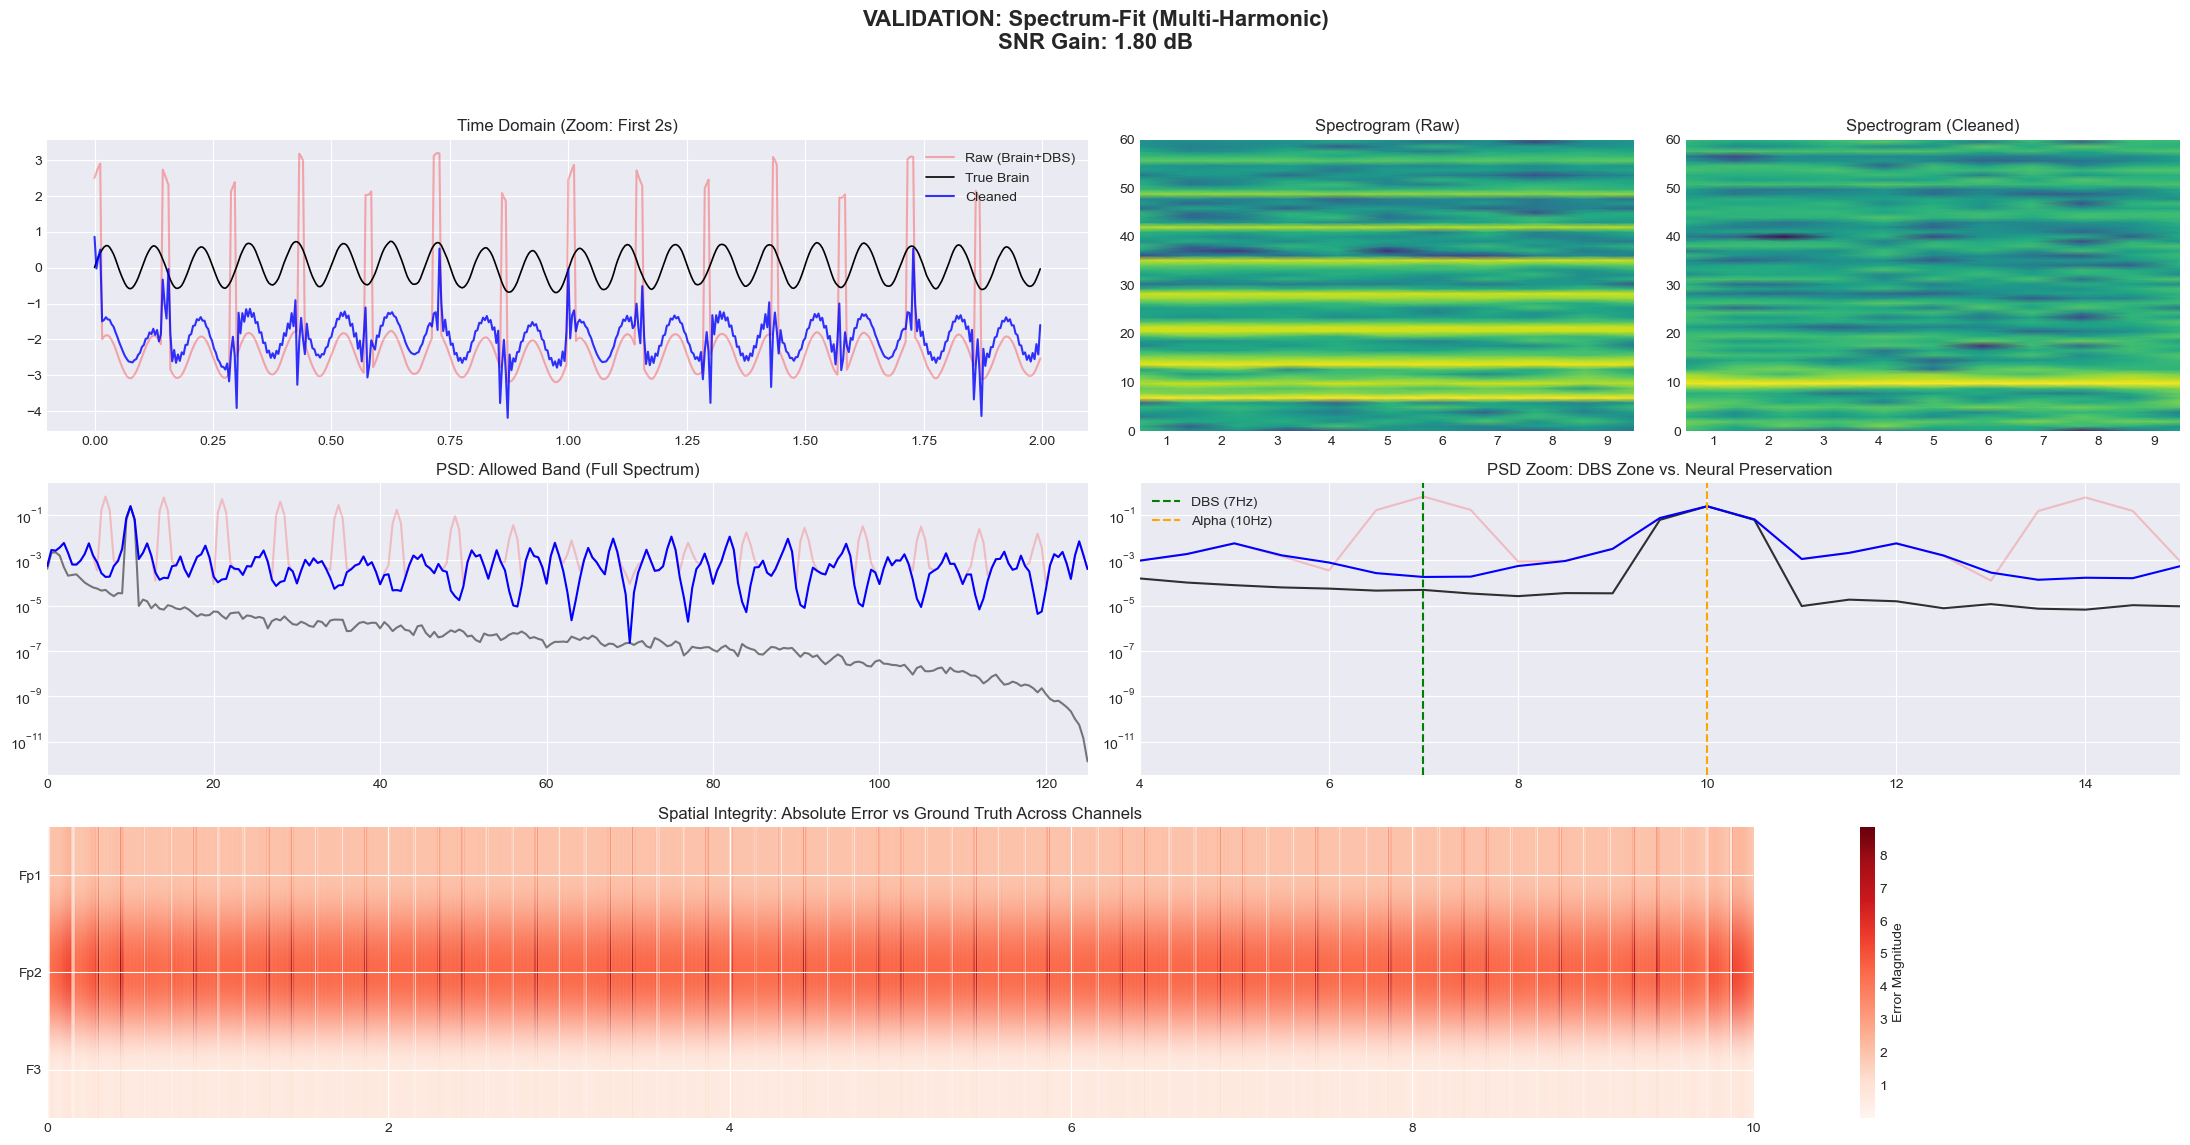

Validating: Hampel Filter (Frequency Domain)...
Running vectorized Freq-Domain Hampel (Allen et al., 2010) - window=2.0Hz, sigmas=3.0, attenuation=-35.0dB
Replaced 265 frequency domain spikes.


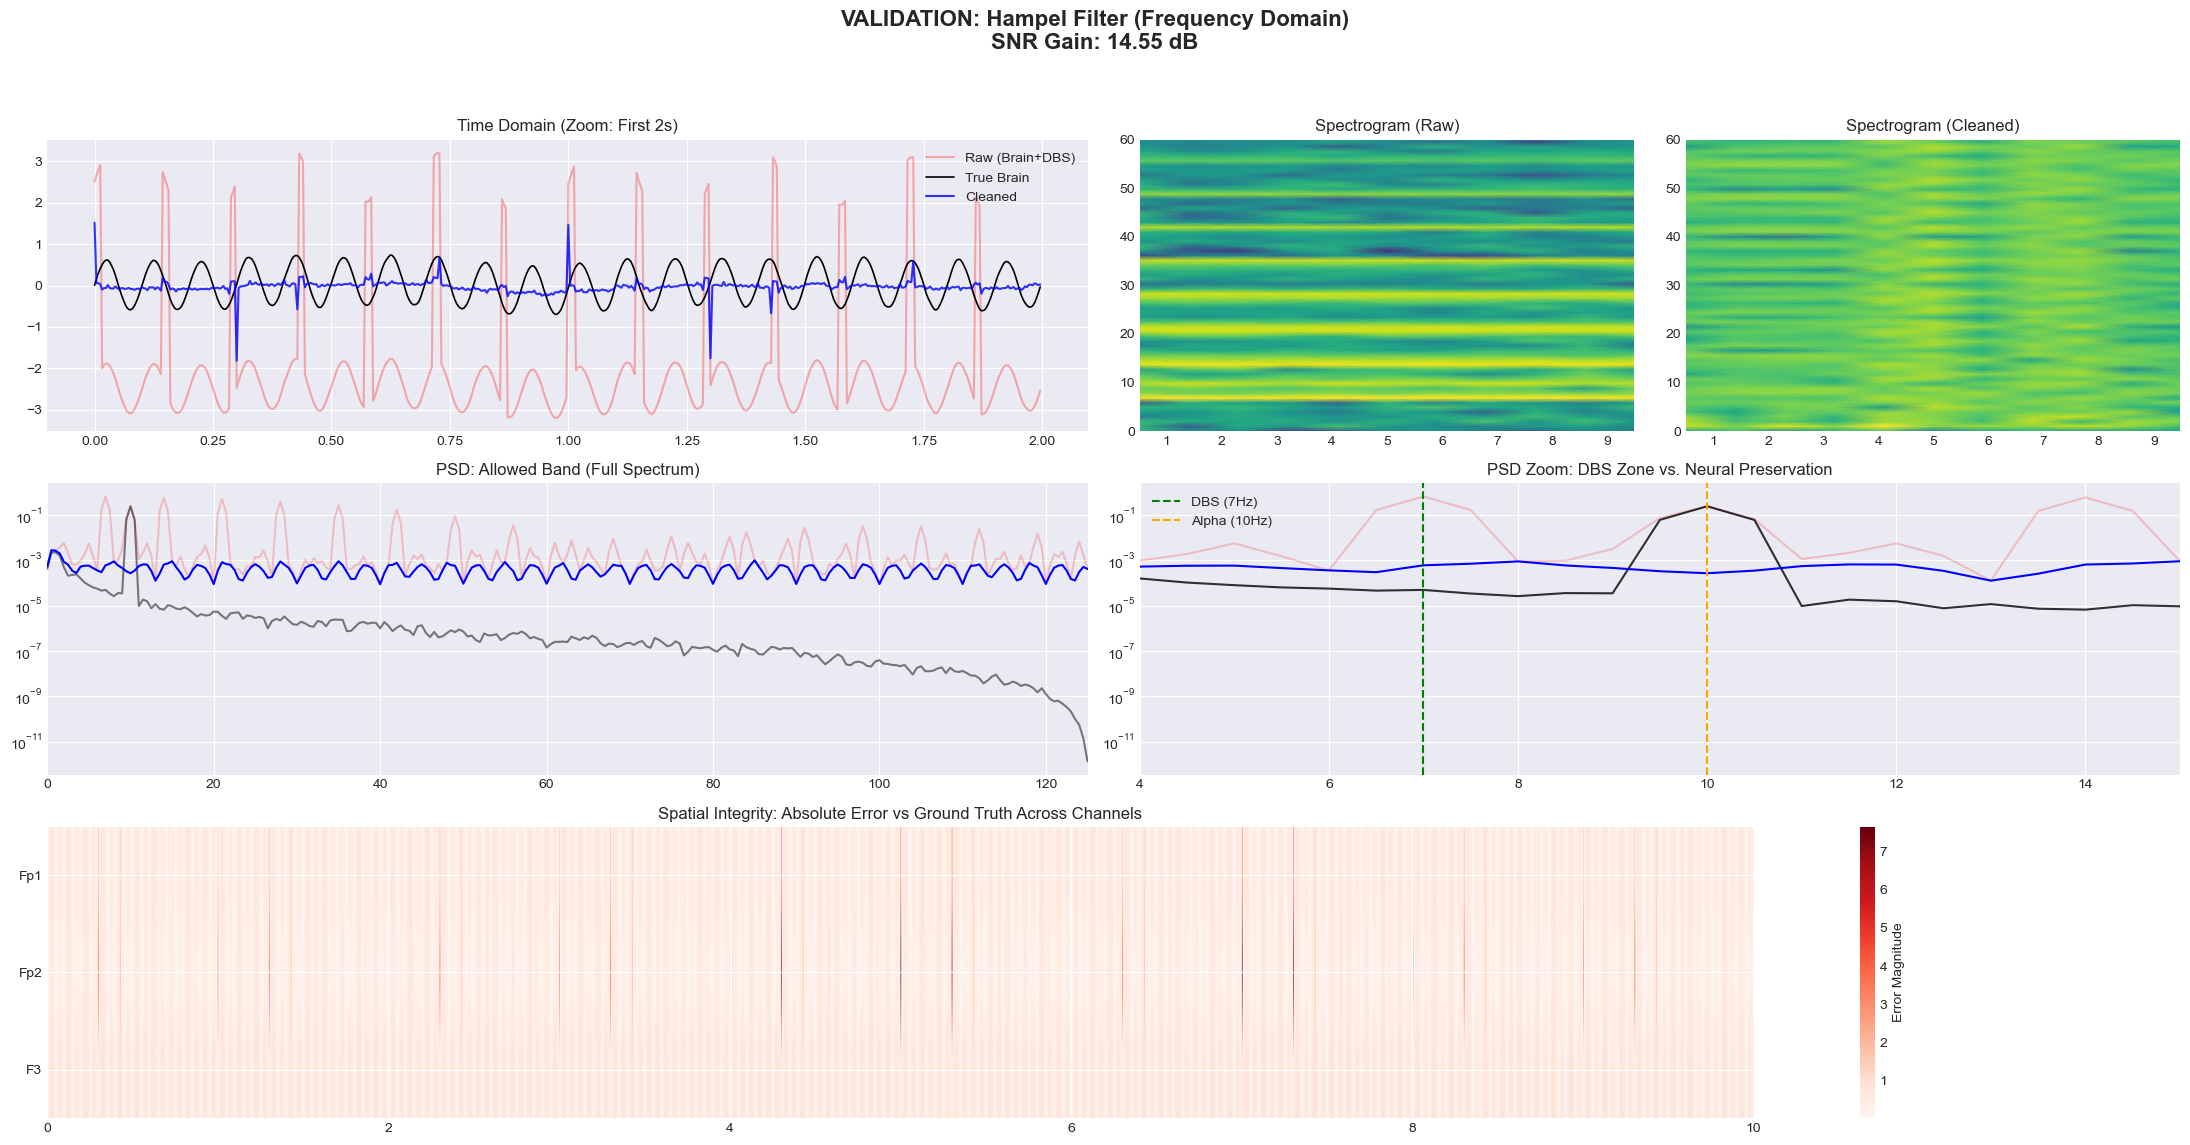

Validating: Hampel Filter (Time Domain)...
Running vectorized Time-Domain Hampel (Allen et al., 2010) - window=51 samples, sigmas=3.0, attenuation=1.0x
  Pass 1: Replaced 541 outlier points.


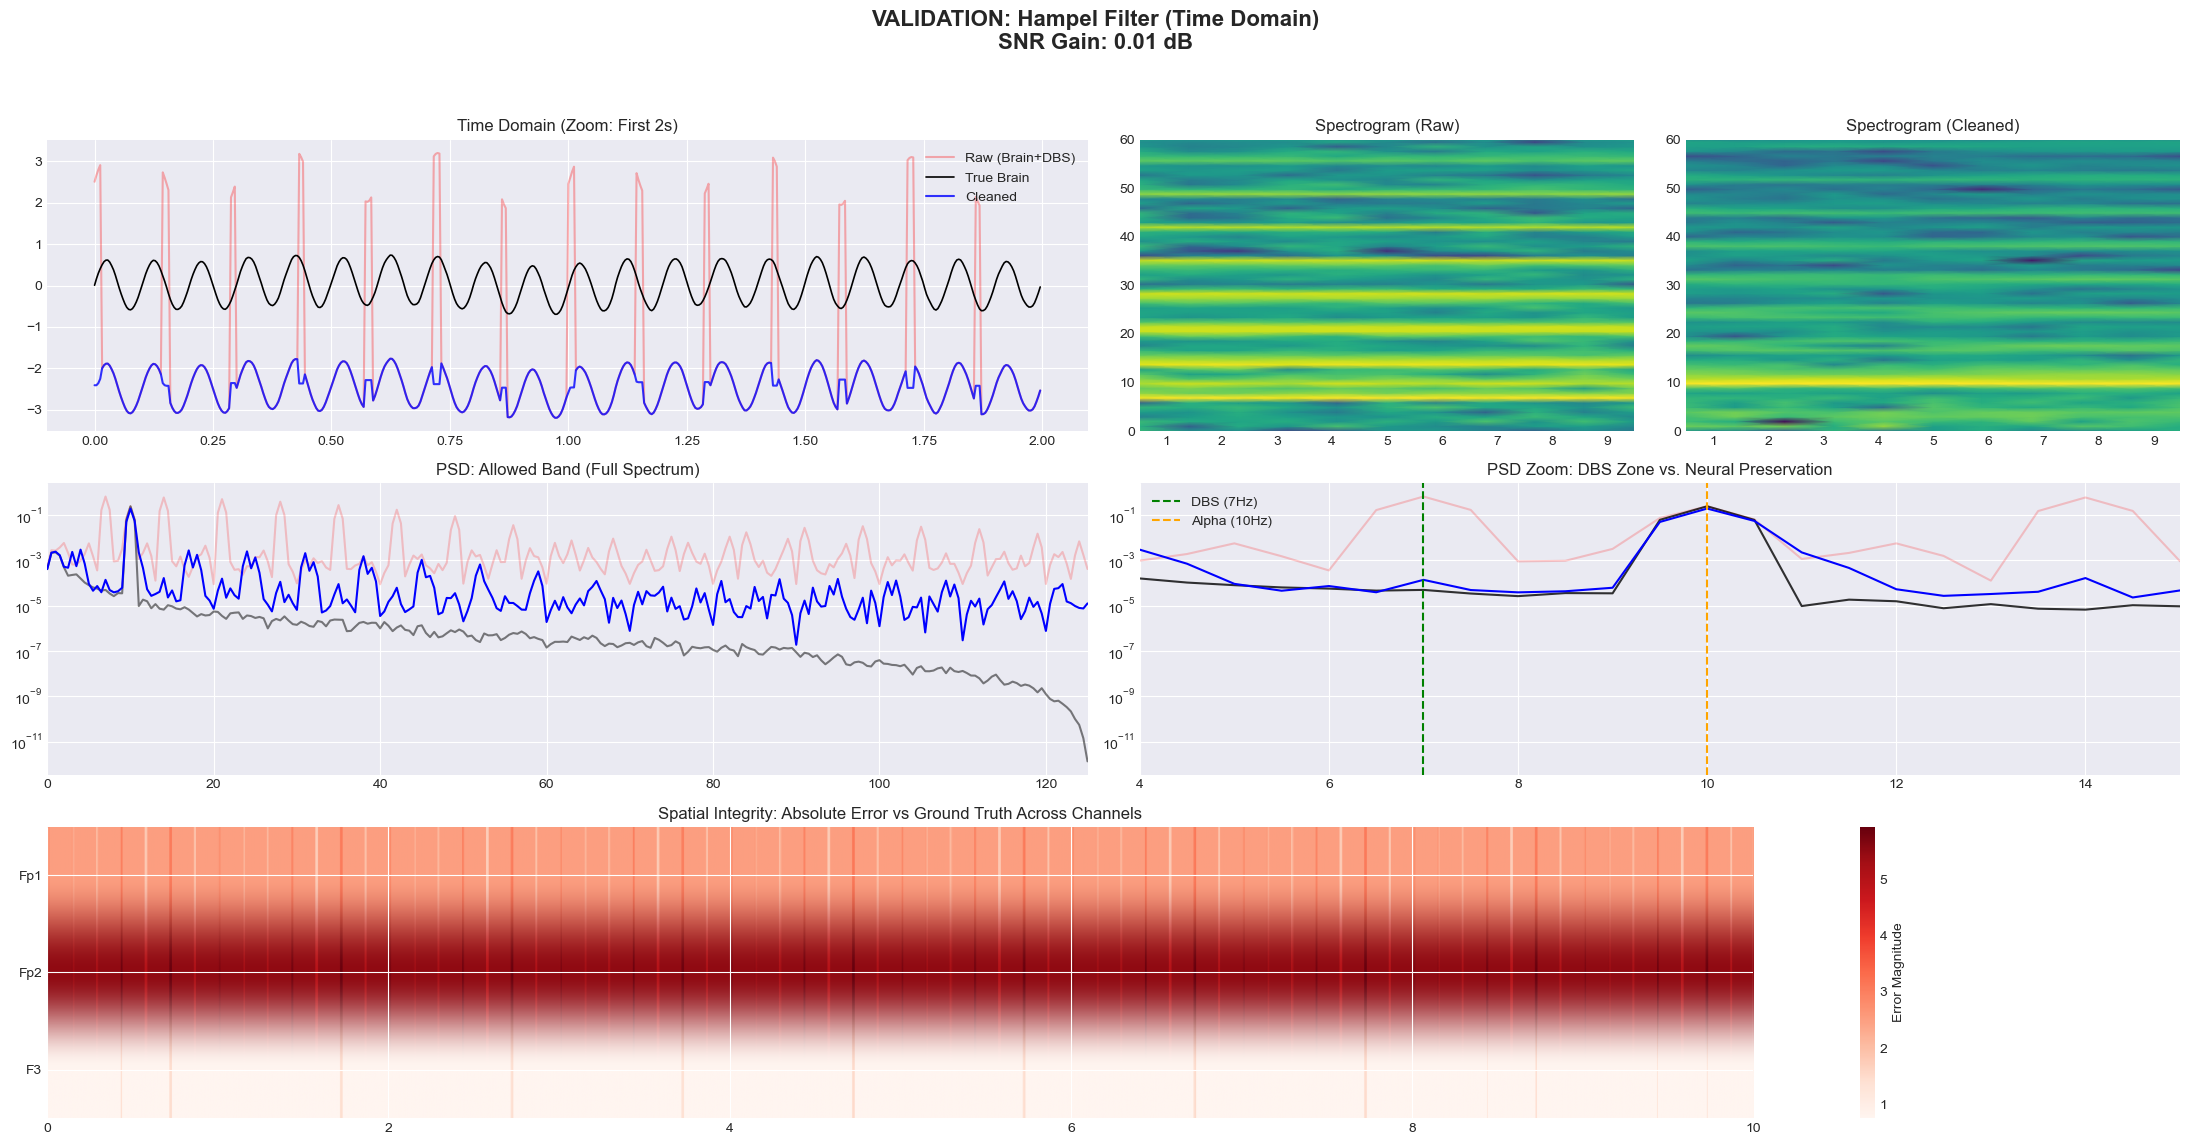

Validating: Zapline+ (Spatial Filtering)...
Applying Zapline+ (Chen et al., 2022) - f=7.0Hz, 12 harmonics, threshold=95.0th percentile


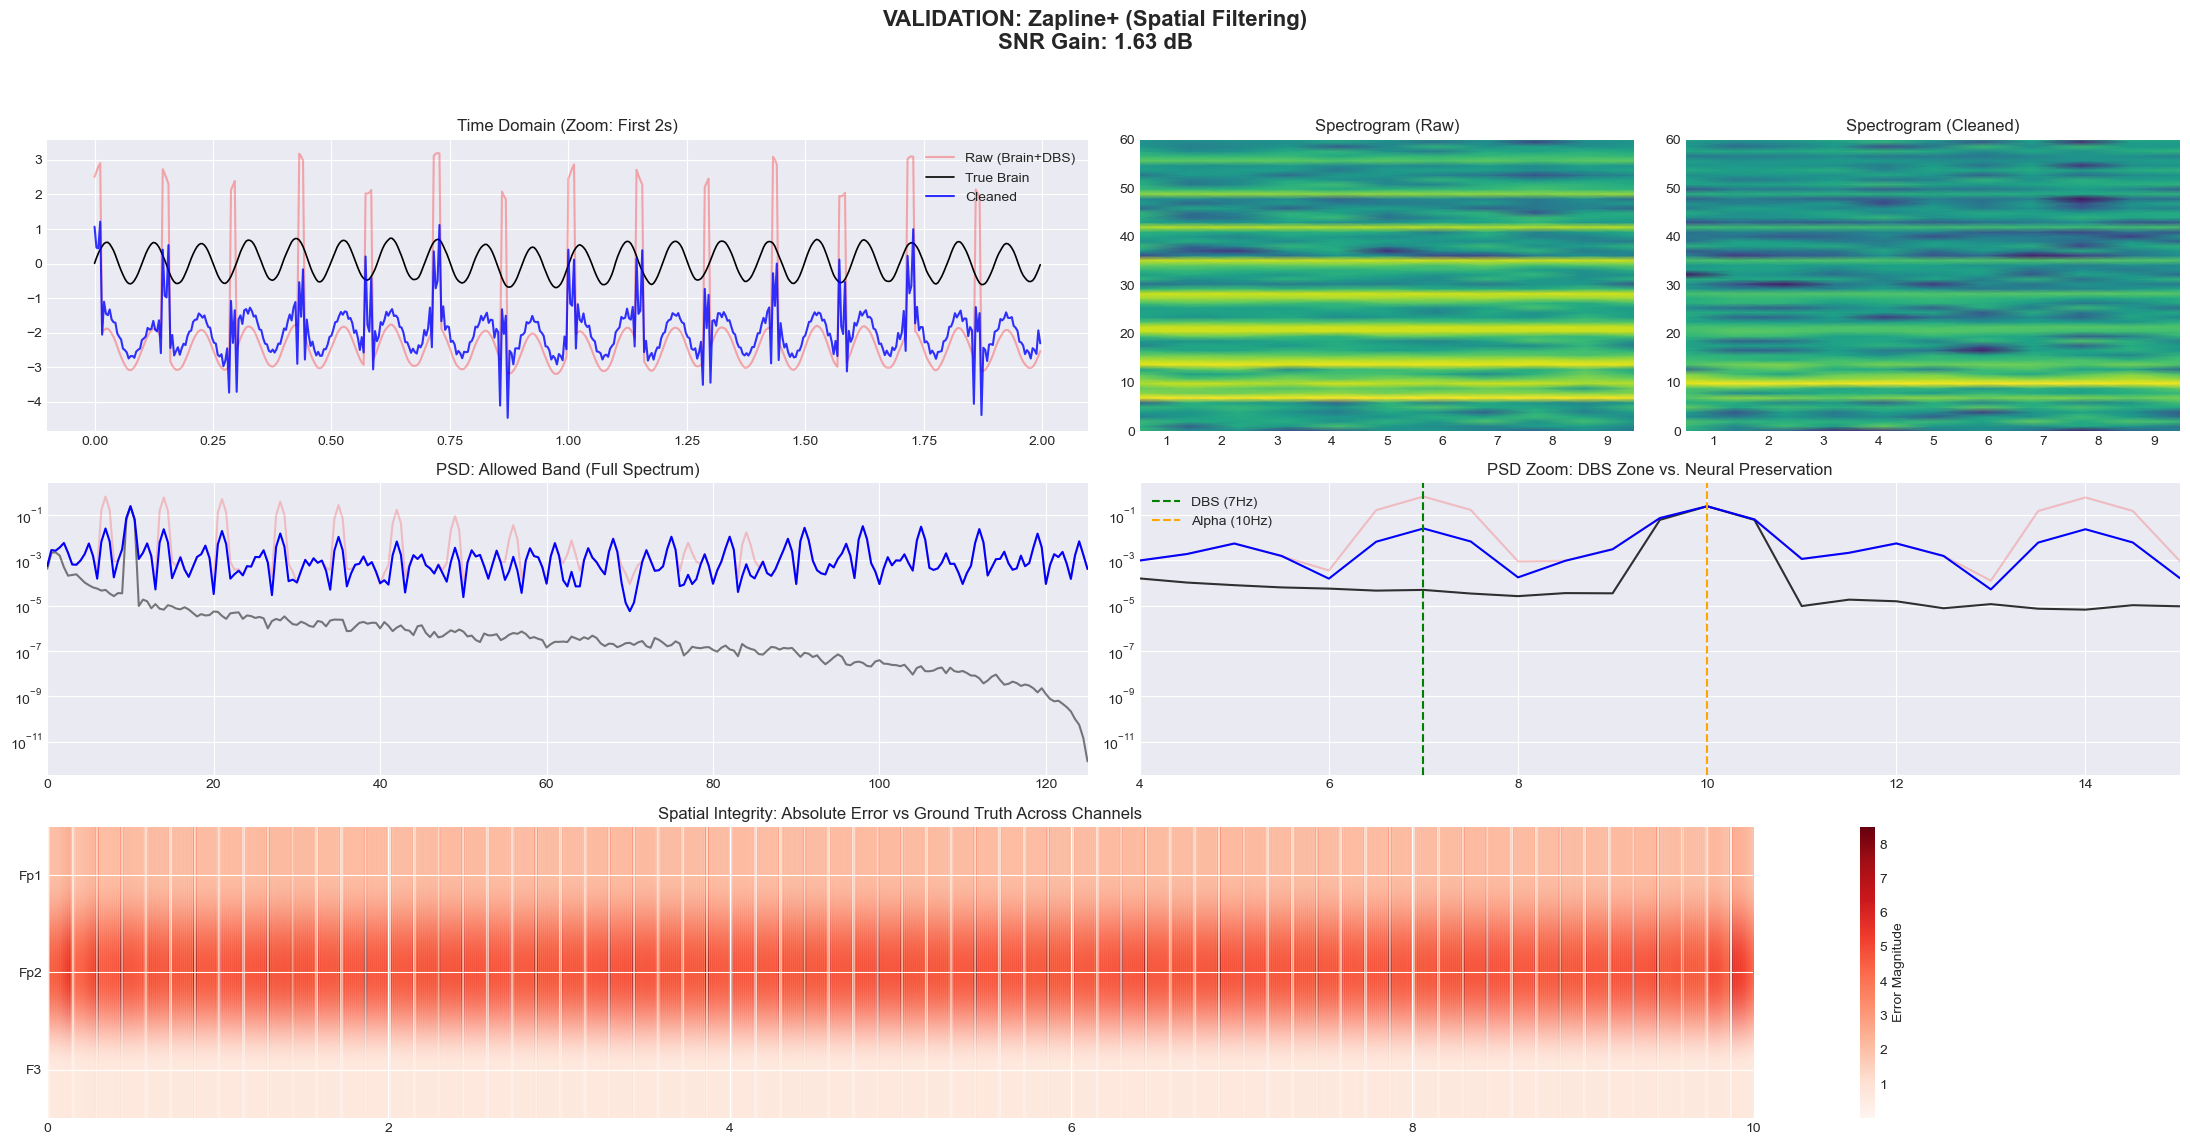

Validating: Comb Notch Filter...
Applying Comb Filter (f0=7.0Hz, Q=35.0)


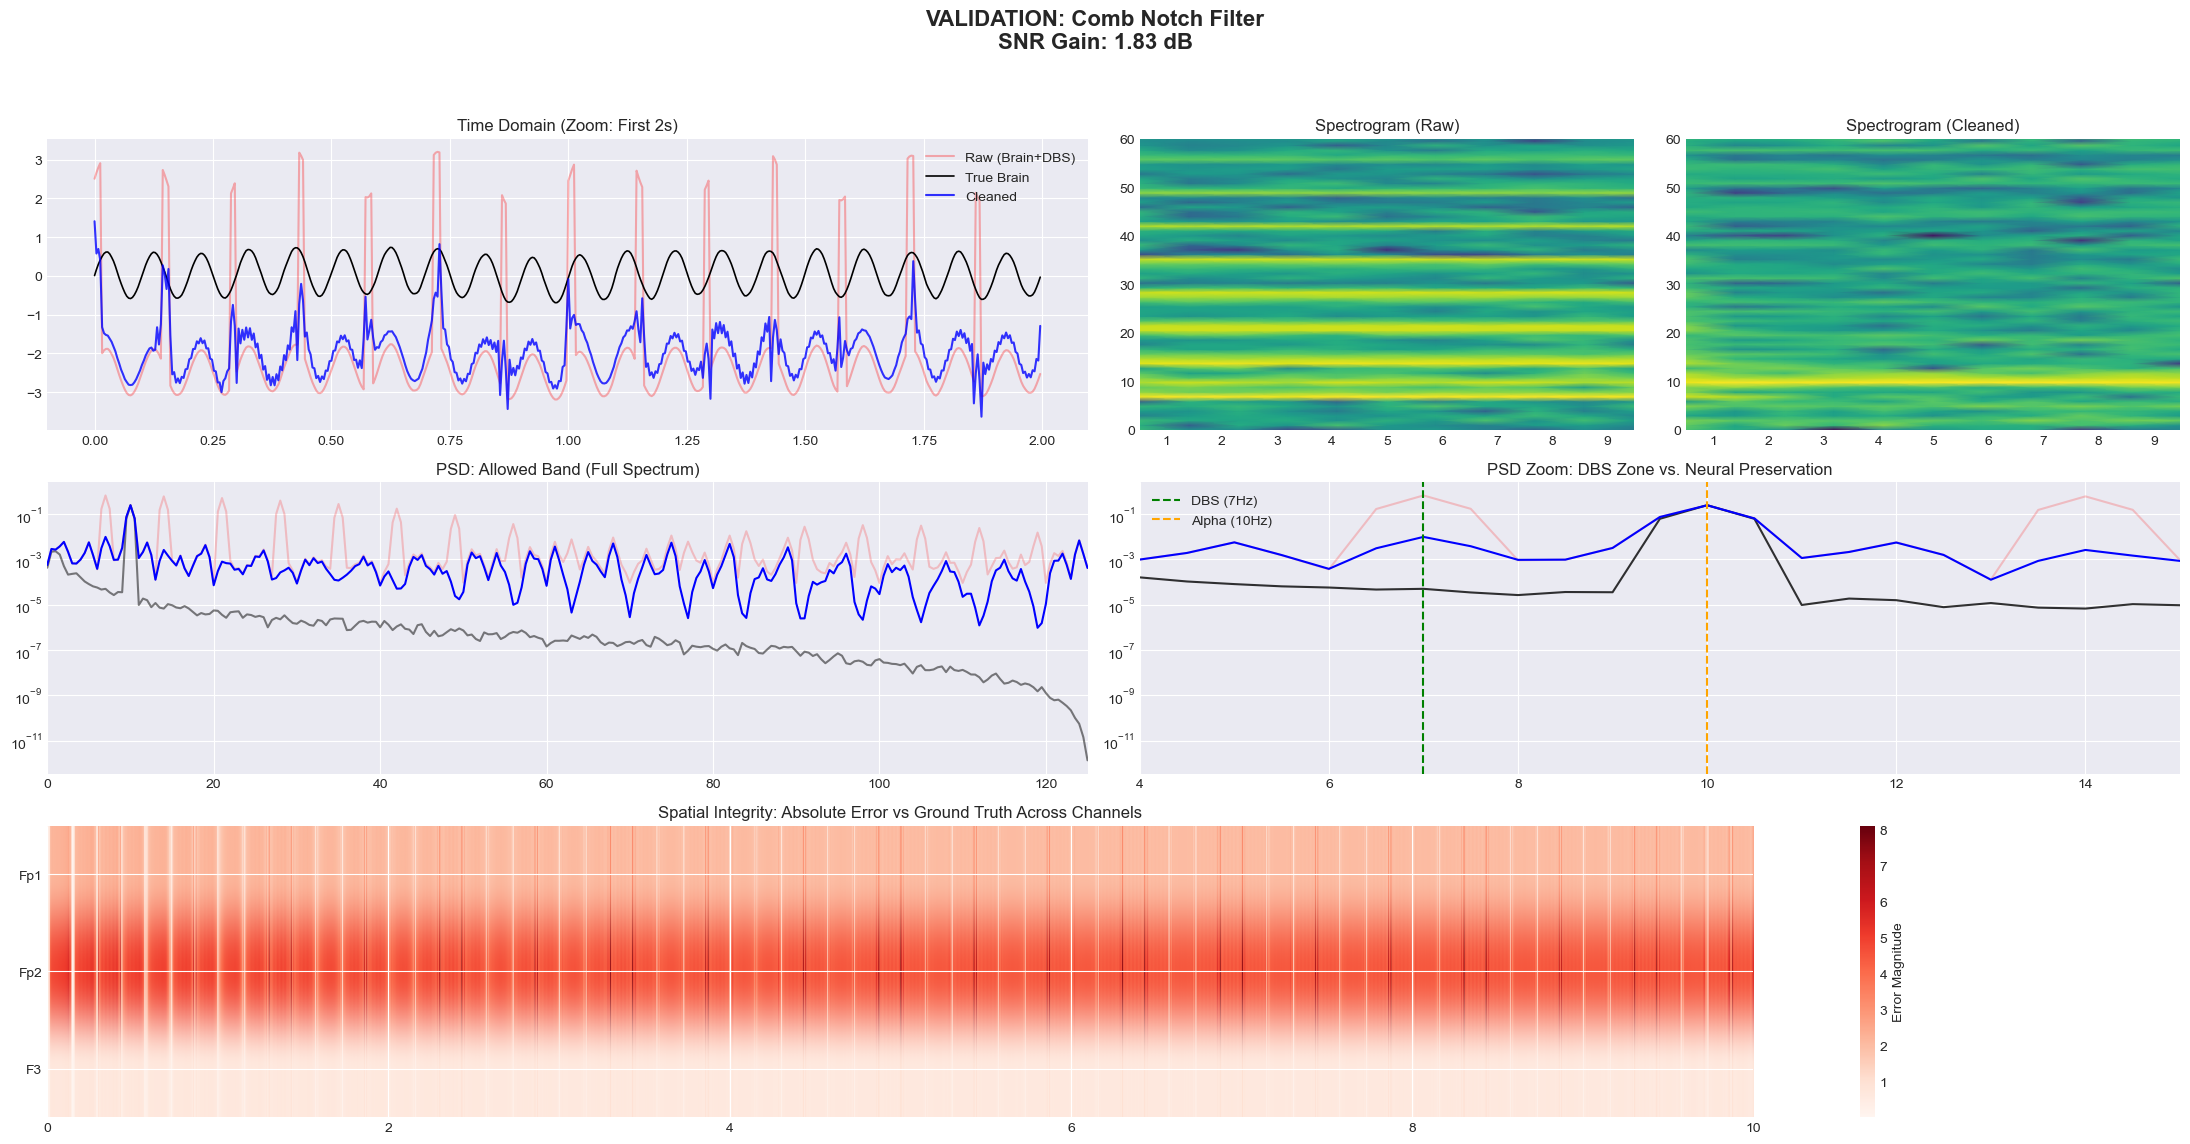

In [89]:
dbs_target_freq = 7.0 # Define target for your config

# Iterate through your provided dictionary
for method_id, config in filter_methods.items():
    try:
        run_advanced_validation(method_id, config, raw_mne, true_mne)
    except Exception as e:
        print(f"Failed to process {method_id}: {e}")

---

# Multi Frequency DBS Removal & ICA

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, ndimage
import mne
import warnings

from pathlib import Path
import sys

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir()), None)
if project_root is None:
    raise ModuleNotFoundError("Could not locate the project root containing 'src'.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.filters import ArtifactFilterFactory

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

print("Imported necessary libraries and set up environment.")

Imported necessary libraries and set up environment.


In [34]:
fs = 250.0
duration = 15.0  
t = np.arange(0, duration, 1/fs)
ch_names = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']
n_channels = len(ch_names)

# Ground Truth (1/f + 7Hz Theta + 10Hz Alpha)
b, a = signal.butter(1, 0.5, btype='low', fs=fs)
s_true = np.zeros((n_channels, len(t)))
for i in range(n_channels):
    brain = signal.lfilter(b, a, np.random.randn(len(t)))
    # Add a genuine 7 Hz brain signal to ensure our filter doesn't destroy it
    theta = 0.8 * np.sin(2 * np.pi * 7.0 * t + np.random.rand())
    alpha = 0.5 * np.sin(2 * np.pi * 10.0 * t + np.random.rand())
    s_true[i] = brain + theta + alpha

# Artifacts: 7Hz DBS Square Wave, Blinks, Muscle
s_dbs = 2.5 * signal.square(2 * np.pi * 7.0 * t, duty=0.1)
s_blink = np.zeros_like(t)
for idx in np.random.choice(len(t) - int(fs), int(duration * 1.5), replace=False):
    s_blink[idx:idx+int(fs*0.3)] += signal.windows.hann(int(fs*0.3)) * 8.0
s_muscle = np.zeros_like(t)
for idx in np.random.choice(len(t) - int(fs), int(duration * 2.5), replace=False):
    bm, am = signal.butter(3, [20, 90], btype='bandpass', fs=fs)
    s_muscle[idx:idx+int(fs*0.2)] += signal.filtfilt(bm, am, np.random.randn(int(fs*0.2))) * 4.0

# Spatial Mixing
data_raw = np.zeros((n_channels, len(t)))
for i, ch in enumerate(ch_names):
    data_raw[i] = s_true[i] + (s_dbs * 1.5) # DBS everywhere
    if ch in ['Fp1', 'Fp2']: data_raw[i] += s_blink * 2.0
    if ch in ['T3', 'T4', 'T5', 'T6']: data_raw[i] += s_muscle * 1.5

info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=['eeg']*n_channels)
info.set_montage('standard_1020')
raw_mne = mne.io.RawArray(data_raw, info)

In [35]:
print("1. Original data loaded.")

# Filter DBS using your factory (Freq-Domain Hampel)
cleaned_array = ArtifactFilterFactory.process(
    method='hampel_freq', 
    data=raw_mne.get_data(), 
    sfreq=fs, 
    window_hz=1.5,   # Tight window to isolate the 7Hz spike
    n_sigmas=3.0, 
    attenuation_db=-80.0
)
print("2. DBS square wave removed via ArtifactFilterFactory.")

# Wrap back into MNE for ICA processing
raw_dbs_clean = mne.io.RawArray(cleaned_array, info)
raw_dbs_clean.filter(l_freq=1.0, h_freq=100.0) # Broad bandpass

# ICA for Blinks & Muscle
ica = mne.preprocessing.ICA(n_components=15, random_state=42, max_iter='auto')
ica.fit(raw_dbs_clean)

# Auto-detect EOG (using Fp1)
eog_indices, _ = ica.find_bads_eog(raw_dbs_clean, ch_name='Fp1')

# Auto-detect EMG (spectral thresholding for high frequency power)
muscle_indices = []
ica_sources = ica.get_sources(raw_dbs_clean).get_data()
for i, comp in enumerate(ica_sources):
    f_ica, p_ica = signal.welch(comp, fs, nperseg=int(fs))
    if np.sum(p_ica[(f_ica >= 20)]) / np.sum(p_ica[(f_ica >= 1) & (f_ica < 20)]) > 0.5:
        muscle_indices.append(i)
muscle_indices = list(set(muscle_indices) - set(eog_indices))

ica.exclude = eog_indices + muscle_indices
raw_final = raw_dbs_clean.copy()
ica.apply(raw_final)
print(f"3. ICA Applied. Removed EOG: {eog_indices}, Removed EMG: {muscle_indices}")

1. Original data loaded.
Running vectorized Freq-Domain Hampel (Allen et al., 2010) - window=1.5Hz, sigmas=3.0, attenuation=-80.0dB
Replaced 1581 frequency domain spikes.
2. DBS square wave removed via ArtifactFilterFactory.
3. ICA Applied. Removed EOG: [], Removed EMG: [0, 4]


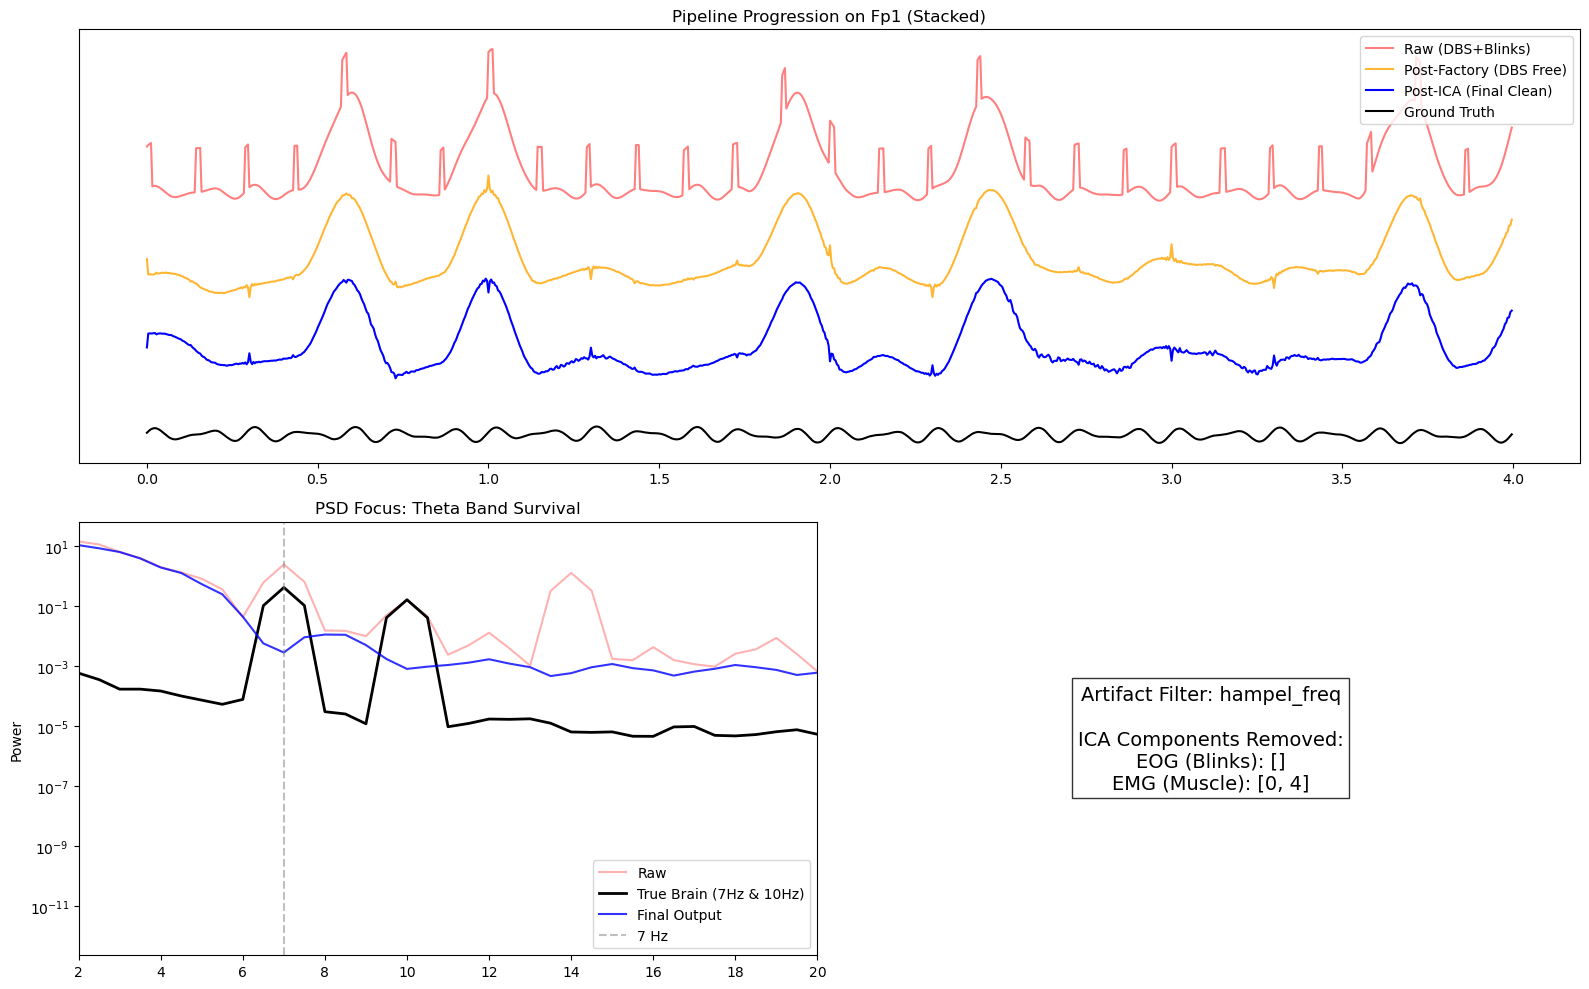

In [36]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)
ch_idx = 0 # Visualizing Fp1

# Time Domain Stack
ax1 = fig.add_subplot(gs[0, :])
time_limit = int(fs * 4)
ax1.plot(t[:time_limit], data_raw[ch_idx, :time_limit] + 20, 'r', alpha=0.5, label='Raw (DBS+Blinks)')
ax1.plot(t[:time_limit], cleaned_array[ch_idx, :time_limit] + 5, 'orange', alpha=0.8, label='Post-Factory (DBS Free)')
ax1.plot(t[:time_limit], raw_final.get_data()[ch_idx, :time_limit] - 10, 'b', label='Post-ICA (Final Clean)')
ax1.plot(t[:time_limit], s_true[ch_idx, :time_limit] - 25, 'k', linewidth=1.5, label='Ground Truth')
ax1.set_title("Pipeline Progression on Fp1 (Stacked)")
ax1.legend(loc='upper right')
ax1.set_yticks([])

# PSD Comparison
ax2 = fig.add_subplot(gs[1, 0])
f, p_raw = signal.welch(data_raw[ch_idx], fs, nperseg=int(fs*2))
_, p_final = signal.welch(raw_final.get_data()[ch_idx], fs, nperseg=int(fs*2))
_, p_true = signal.welch(s_true[ch_idx], fs, nperseg=int(fs*2))

ax2.semilogy(f, p_raw, 'r', alpha=0.3, label='Raw')
ax2.semilogy(f, p_true, 'k', linewidth=2, label='True Brain (7Hz & 10Hz)')
ax2.semilogy(f, p_final, 'b', alpha=0.8, label='Final Output')
ax2.set_xlim([2, 20])
ax2.axvline(7, color='grey', linestyle='--', alpha=0.5, label='7 Hz')
ax2.set_title("PSD Focus: Theta Band Survival")
ax2.set_ylabel("Power")
ax2.legend()

# Spatial Map Info
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
ax3.text(0.5, 0.5, f"Artifact Filter: hampel_freq\n\nICA Components Removed:\nEOG (Blinks): {eog_indices}\nEMG (Muscle): {muscle_indices}", 
         ha='center', va='center', fontsize=14, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# TESTING

In [37]:
# [CELL 1] SYSTEM SETUP & ARTIFACT FILTER FACTORY
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, ndimage
import mne
import warnings

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

class ArtifactFilterFactory:
    """Highly-vectorized filtering implementations for EEG ND arrays."""
    
    MAD_SCALE_FACTOR = 1.4826
    
    @classmethod
    def process(cls, method: str, data: np.ndarray, sfreq: float, **kwargs) -> np.ndarray:
        method = method.lower().strip()
        method_aliases = {
            'time_domain_hampel': 'hampel_time',
            'freq_domain_hampel': 'hampel_freq',
            'spectral_interpolation': 'spectrum_fit',
            'chen': 'zapline',
        }
        method = method_aliases.get(method, method)
        
        original_shape = data.shape
        if data.ndim == 1: data = data.reshape(1, -1)
        
        if method == 'hampel_time':
            clean_data = cls._apply_time_domain_hampel(data, sfreq, **kwargs)
        elif method == 'hampel_freq':
            clean_data = cls._apply_freq_domain_hampel(data, sfreq, **kwargs)
        elif method == 'spectrum_fit':
            clean_data = cls._apply_spectral_interpolation(data, sfreq, **kwargs)
        elif method == 'zapline':
            clean_data = cls._apply_zapline(data, sfreq, **kwargs)
        elif method == 'comb_notch':
            clean_data = cls._apply_comb_notch(data, sfreq, **kwargs)
        else:
            raise ValueError(f"Unknown method '{method}'.")
            
        return clean_data.reshape(original_shape)

    @staticmethod
    def _fold_to_nyquist(freq_hz: float, sfreq: float) -> float:
        nyquist = sfreq / 2.0
        if freq_hz < nyquist: return freq_hz
        folded = abs(((freq_hz + nyquist) % (2 * nyquist)) - nyquist)
        if np.isclose(folded, 0.0): folded = nyquist * 0.95
        return min(folded, nyquist * 0.999)

    @staticmethod
    def _apply_time_domain_hampel(data: np.ndarray, sfreq: float, window_sec: float = 0.2, n_sigmas: float = 3.0, attenuation_factor: float = 1.0) -> np.ndarray:
        k = max(3, int(window_sec * sfreq) | 1)
        cleaned_data = np.copy(data)
        n_passes = max(1, int(np.ceil(attenuation_factor)))
        
        for pass_num in range(n_passes):
            rolling_median = ndimage.median_filter(cleaned_data, size=(1, k), mode='reflect')
            abs_deviation = np.abs(cleaned_data - rolling_median)
            rolling_mad = ndimage.median_filter(abs_deviation, size=(1, k), mode='reflect')
            threshold = np.maximum(n_sigmas * ArtifactFilterFactory.MAD_SCALE_FACTOR * rolling_mad, 1e-10)
            outlier_mask = abs_deviation > threshold
            
            if pass_num < n_passes - 1:
                cleaned_data[outlier_mask] = cleaned_data[outlier_mask] * 0.5 + rolling_median[outlier_mask] * 0.5
            else:
                cleaned_data[outlier_mask] = rolling_median[outlier_mask]
        return cleaned_data

    @staticmethod
    def _apply_freq_domain_hampel(data: np.ndarray, sfreq: float, window_hz: float = 2.0, n_sigmas: float = 3.0, attenuation_db: float = -60.0) -> np.ndarray:
        n_samples = data.shape[1]
        k = max(3, int(window_hz / (sfreq / n_samples)) | 1)
        
        S = np.fft.rfft(data, axis=1)
        magnitudes, phases = np.abs(S), np.angle(S)
        
        rolling_median_mag = ndimage.median_filter(magnitudes, size=(1, k), mode='reflect')
        abs_dev = np.abs(magnitudes - rolling_median_mag)
        rolling_mad = ndimage.median_filter(abs_dev, size=(1, k), mode='reflect')
        
        threshold = np.maximum(n_sigmas * ArtifactFilterFactory.MAD_SCALE_FACTOR * rolling_mad, 1e-10)
        outlier_mask = abs_dev > threshold
        
        attenuation_linear = 10 ** (attenuation_db / 20.0)
        clean_mags = np.copy(magnitudes)
        clean_mags[outlier_mask] = (1 - attenuation_linear) * rolling_median_mag[outlier_mask] + attenuation_linear * clean_mags[outlier_mask]
        
        S_clean = clean_mags * np.exp(1j * phases)
        return np.fft.irfft(S_clean, n=n_samples, axis=1)

    @staticmethod
    def _apply_comb_notch(data: np.ndarray, sfreq: float, f0: float = 7.0, q_factor: float = 30.0) -> np.ndarray:
        f0 = ArtifactFilterFactory._fold_to_nyquist(float(f0), sfreq)
        nyq = sfreq / 2.0
        cleaned_data = np.copy(data)
        for h in np.arange(f0, nyq, f0):
            if h > 0 and h < nyq:
                b, a = signal.iirnotch(w0=h, Q=q_factor, fs=sfreq)
                cleaned_data = signal.filtfilt(b, a, cleaned_data, axis=1)
        return cleaned_data

    @staticmethod
    def _apply_spectral_interpolation(data: np.ndarray, sfreq: float, f_target: float = 7.0, bandwidth: float = 2.0, chunk_sec: float = 10.0, attenuation_db: float = -60.0) -> np.ndarray:
        f_target = ArtifactFilterFactory._fold_to_nyquist(float(f_target), sfreq)
        nperseg = min(int(sfreq * chunk_sec), data.shape[1])
        
        stft_channels = []
        for ch in range(data.shape[0]):
            f_ch, t_ch, z_ch = signal.stft(data[ch], fs=sfreq, nperseg=nperseg)
            if ch == 0: f = f_ch
            stft_channels.append(z_ch)
        Zxx = np.stack(stft_channels, axis=0)
        
        gain_mask = np.ones_like(f)
        half_bw, taper_width = bandwidth / 2.0, bandwidth / 4.0
        attenuation_linear = 10 ** (attenuation_db / 20.0)
        
        for harm in np.arange(f_target, sfreq / 2.0, f_target):
            lower, upper = harm - half_bw, harm + half_bw
            gain_mask[(f >= lower) & (f <= upper)] = attenuation_linear
            
            for idx in np.where((f >= lower - taper_width) & (f < lower))[0]:
                alpha = (f[idx] - (lower - taper_width)) / taper_width
                gain_mask[idx] = 1.0 - (1.0 - attenuation_linear) * (0.5 * (1 + np.cos(np.pi * (1 - alpha))))
            for idx in np.where((f > upper) & (f <= upper + taper_width))[0]:
                alpha = (f[idx] - upper) / taper_width
                gain_mask[idx] = 1.0 - (1.0 - attenuation_linear) * (0.5 * (1 + np.cos(np.pi * alpha)))
        
        Zxx_clean = Zxx * gain_mask[np.newaxis, :, np.newaxis]
        cleaned_data = np.zeros_like(data)
        for ch in range(data.shape[0]):
            _, cleaned_ch = signal.istft(Zxx_clean[ch], fs=sfreq, nperseg=nperseg)
            cleaned_data[ch, :min(data.shape[1], len(cleaned_ch))] = cleaned_ch[:data.shape[1]]
        return cleaned_data

    @staticmethod
    def _apply_zapline(data: np.ndarray, sfreq: float, f_target: float = 7.0, n_harmonics: int = 10, threshold_percentile: float = 95.0, chunk_sec: float = 2.0) -> np.ndarray:
        f_target = ArtifactFilterFactory._fold_to_nyquist(float(f_target), sfreq)
        n_channels, n_samples = data.shape
        nperseg = min(int(sfreq * chunk_sec), n_samples)
        
        stft_channels = []
        for ch in range(n_channels):
            f_ch, t_ch, z_ch = signal.stft(data[ch], fs=sfreq, nperseg=nperseg)
            if ch == 0: f = f_ch
            stft_channels.append(z_ch)
        Zxx = np.stack(stft_channels, axis=0)
        
        nyquist = sfreq / 2.0
        harmonics = np.arange(f_target, min(nyquist, f_target * (n_harmonics + 1)), f_target)
        Zxx_clean = np.copy(Zxx)
        
        for harmonic in harmonics:
            harmonic_bins = np.where(np.abs(f - harmonic) <= 1.0)[0]
            if len(harmonic_bins) == 0: continue
            
            X_harmonic = Zxx[:, harmonic_bins, :]
            X_reshaped = X_harmonic.reshape(n_channels, -1)
            C = np.cov(X_reshaped)
            
            try:
                eigvals, eigvecs = np.linalg.eigh(C)
                idx_sort = np.argsort(eigvals)[::-1]
                n_artifact_vecs = max(1, min(2, n_channels // 2))
                artifact_vecs = eigvecs[:, idx_sort[:n_artifact_vecs]]
                
                proj = artifact_vecs @ artifact_vecs.T @ X_reshaped
                Zxx_clean[:, harmonic_bins, :] -= 0.8 * proj.reshape(X_harmonic.shape)
            except np.linalg.LinAlgError:
                Zxx_clean[:, harmonic_bins, :] *= 0.5
                
        cleaned_data = np.zeros_like(data)
        for ch in range(n_channels):
            _, cleaned_ch = signal.istft(Zxx_clean[ch], fs=sfreq, nperseg=nperseg)
            cleaned_data[ch, :min(data.shape[1], len(cleaned_ch))] = cleaned_ch[:data.shape[1]]
        return cleaned_data

In [38]:
# [CELL 2] GENERATE 10-20 SYNTHETIC DATA
fs = 250.0
duration = 15.0  
t = np.arange(0, duration, 1/fs)
ch_names = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']
n_channels = len(ch_names)

# Ground Truth (1/f + 7Hz Theta + 10Hz Alpha)
b, a = signal.butter(1, 0.5, btype='low', fs=fs)
s_true = np.zeros((n_channels, len(t)))
for i in range(n_channels):
    brain = signal.lfilter(b, a, np.random.randn(len(t)))
    # Genuine Brain Signals
    theta = 0.8 * np.sin(2 * np.pi * 7.0 * t + np.random.rand())
    alpha = 0.5 * np.sin(2 * np.pi * 10.0 * t + np.random.rand())
    s_true[i] = brain + theta + alpha

# Artifacts: 7Hz DBS Square Wave, Blinks, Muscle
s_dbs = 2.5 * signal.square(2 * np.pi * 7.0 * t, duty=0.1)

s_blink = np.zeros_like(t)
for idx in np.random.choice(len(t) - int(fs), int(duration * 1.5), replace=False):
    s_blink[idx:idx+int(fs*0.3)] += signal.windows.hann(int(fs*0.3)) * 8.0
    
s_muscle = np.zeros_like(t)
for idx in np.random.choice(len(t) - int(fs), int(duration * 2.5), replace=False):
    bm, am = signal.butter(3, [20, 90], btype='bandpass', fs=fs)
    s_muscle[idx:idx+int(fs*0.2)] += signal.filtfilt(bm, am, np.random.randn(int(fs*0.2))) * 4.0

# Spatial Mixing Matrix
data_raw = np.zeros((n_channels, len(t)))
for i, ch in enumerate(ch_names):
    data_raw[i] = s_true[i] + (s_dbs * 1.5) # DBS hits everywhere
    if ch in ['Fp1', 'Fp2']: data_raw[i] += s_blink * 2.0
    if ch in ['T3', 'T4', 'T5', 'T6']: data_raw[i] += s_muscle * 1.5

info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=['eeg']*n_channels)
info.set_montage('standard_1020')
raw_mne = mne.io.RawArray(data_raw, info)

In [41]:
# [CELL 3] BATCH EXPERIMENT & METRICS ENGINE
methods_to_test = ['comb_notch', 'spectrum_fit', 'zapline', 'hampel_time', 'hampel_freq']
results = {}

# Convert Ground Truth to flat array for metric calculations
true_flat = s_true.flatten()
sig_power = np.mean(true_flat**2)

print("Starting Exhaustive Pipeline Comparison...")

for method in methods_to_test:
    print(f"\nEvaluating: {method.upper()}")
    
    # 1. Broad Bandpass First (Standard pre-processing)
    raw_copy = raw_mne.copy()
    raw_copy.filter(l_freq=1.0, h_freq=100.0, verbose=False)
    
    # 2. Apply the specific DBS Filter from the Factory
    # Passing target f=7.0 for the filters that require it
    data=raw_copy.get_data(), 
    sfreq=fs,
    filtered_data = ArtifactFilterFactory.process(
        method=method,
        data=raw_copy.get_data(),
        sfreq=fs,
        **(
            {'f0': 7.0, 'q_factor': 35.0} if method == 'comb_notch' else
            {'f_target': 7.0, 'bandwidth': 1.5, 'attenuation_db': -80.0} if method == 'spectrum_fit' else
            {'f_target': 7.0, 'n_harmonics': 12, 'threshold_percentile': 95.0} if method == 'zapline' else
            {'window_sec': 0.2, 'n_sigmas': 3.0, 'attenuation_factor': 1.0} if method == 'hampel_time' else
            {'window_hz': 1.5, 'n_sigmas': 3.0, 'attenuation_db': -80.0}
        )
    )
    
    # 3. Re-wrap and run ICA to remove Blinks/Muscle
    clean_mne = mne.io.RawArray(filtered_data, info)
    ica = mne.preprocessing.ICA(n_components=15, random_state=42, max_iter='auto')
    ica.fit(clean_mne, verbose=False)
    
    # Auto-reject Blinks
    eog_indices, _ = ica.find_bads_eog(clean_mne, ch_name='Fp1', verbose=False)
    
    # Auto-reject Muscle (High freq dominance)
    muscle_indices = []
    ica_sources = ica.get_sources(clean_mne).get_data()
    for i, comp in enumerate(ica_sources):
        f_ica, p_ica = signal.welch(comp, fs, nperseg=int(fs))
        if np.sum(p_ica[(f_ica >= 20)]) / np.sum(p_ica[(f_ica >= 1) & (f_ica < 20)]) > 0.5:
            muscle_indices.append(i)
    
    ica.exclude = list(set(eog_indices + muscle_indices))
    ica.apply(clean_mne, verbose=False)
    
    final_data = clean_mne.get_data()
    
    # 4. Calculate Objective Metrics
    final_flat = final_data.flatten()
    rmse = np.sqrt(np.mean((true_flat - final_flat)**2))
    noise_power = np.mean((true_flat - final_flat)**2)
    snr = 10 * np.log10(sig_power / noise_power) if noise_power > 0 else 0
    
    results[method] = {
        'data': final_data,
        'rmse': rmse,
        'snr': snr
    }
    print(f"-> SNR: {snr:.2f} dB | RMSE: {rmse:.2f}")

print("\nExperiment Complete.")

Starting Exhaustive Pipeline Comparison...

Evaluating: COMB_NOTCH
-> SNR: -9.13 dB | RMSE: 1.92

Evaluating: SPECTRUM_FIT
-> SNR: -8.30 dB | RMSE: 1.75

Evaluating: ZAPLINE
-> SNR: -8.27 dB | RMSE: 1.74

Evaluating: HAMPEL_TIME
-> SNR: -6.62 dB | RMSE: 1.44

Evaluating: HAMPEL_FREQ
-> SNR: -8.06 dB | RMSE: 1.70

Experiment Complete.


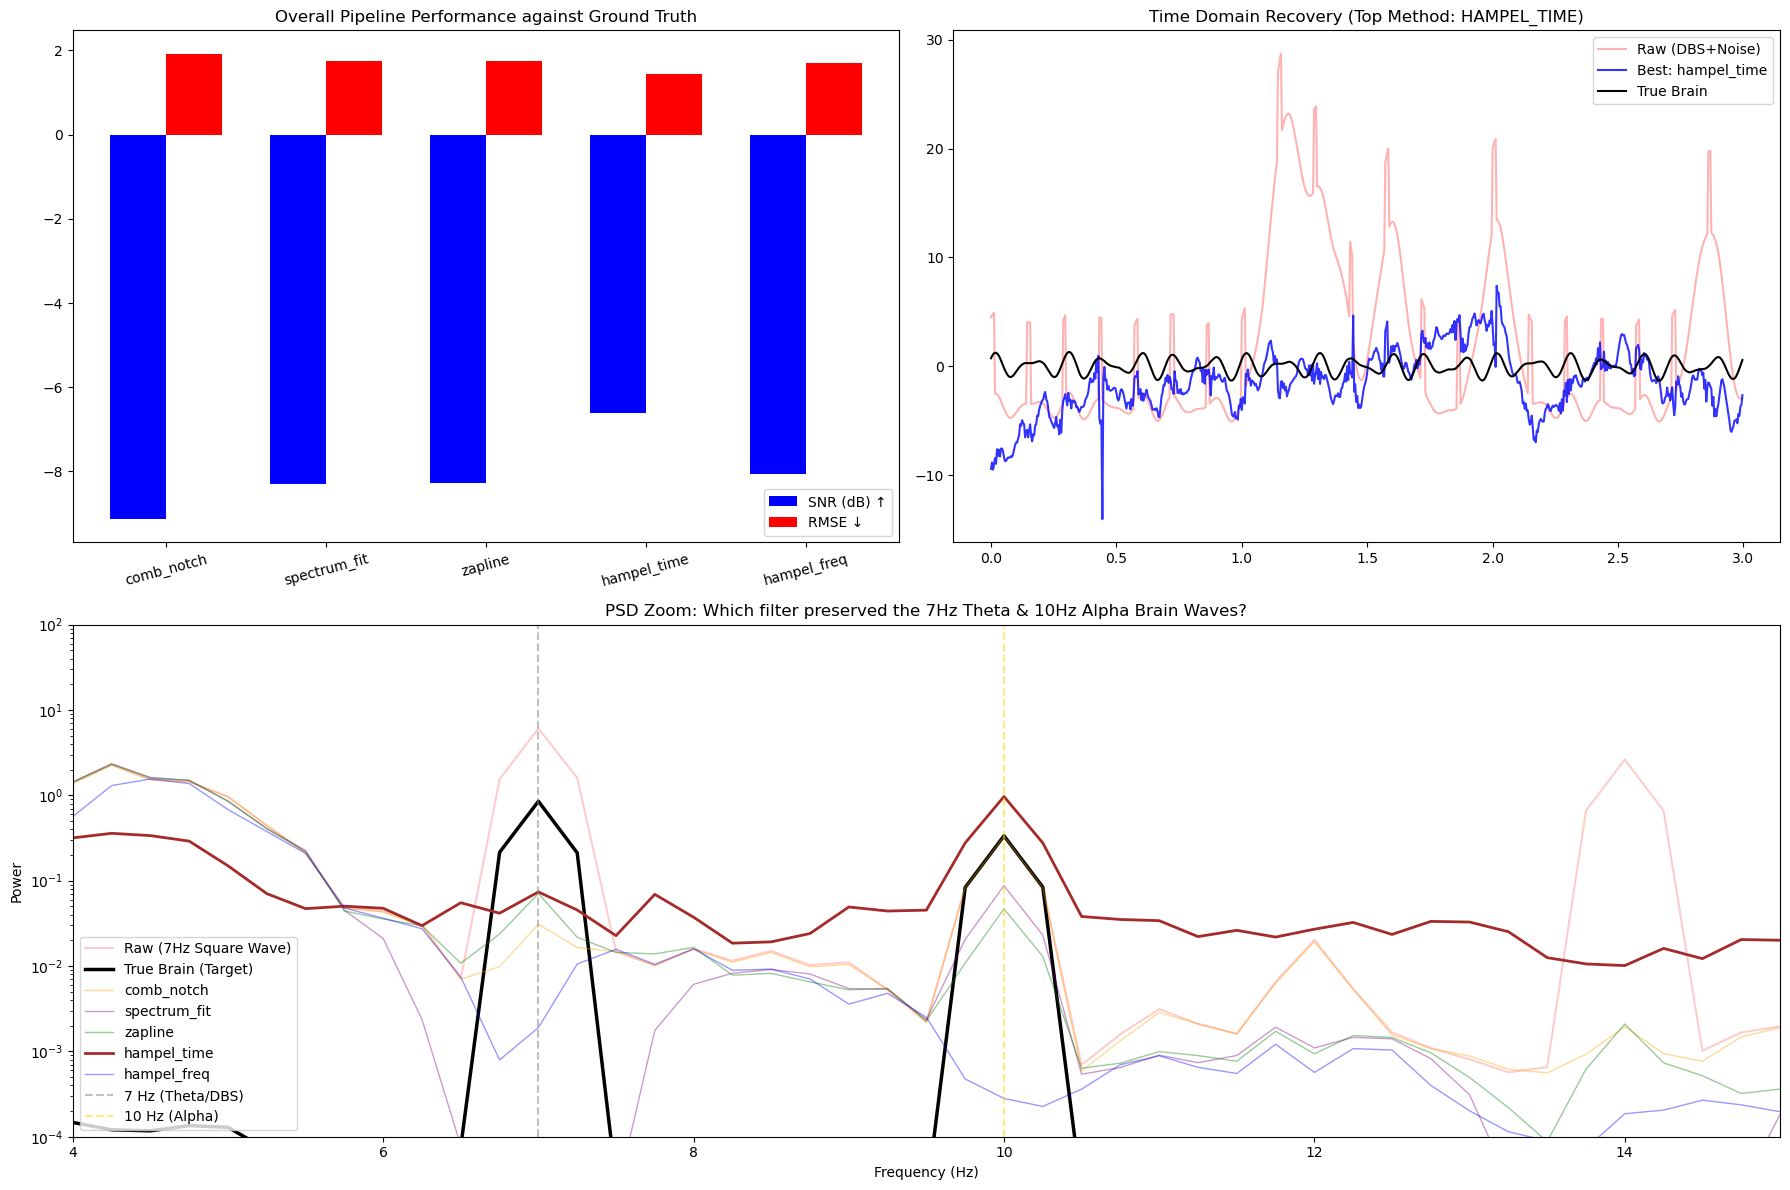

In [42]:
# [CELL 4] VISUALIZATION & VERDICT DASHBOARD
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2)
ch_idx = 0  # Fp1

# 1. Metrics Comparison (Bar Chart)
ax1 = fig.add_subplot(gs[0, 0])
names = list(results.keys())
snr_vals = [results[n]['snr'] for n in names]
rmse_vals = [results[n]['rmse'] for n in names]

x = np.arange(len(names))
width = 0.35

ax1.bar(x - width/2, snr_vals, width, label='SNR (dB) ↑', color='blue')
ax1.bar(x + width/2, rmse_vals, width, label='RMSE ↓', color='red')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=15)
ax1.set_title("Overall Pipeline Performance against Ground Truth")
ax1.legend()

# 2. Time Domain Comparison (Zoom on best method vs ground truth)
best_method = max(results, key=lambda k: results[k]['snr'])
ax2 = fig.add_subplot(gs[0, 1])
t_plot = int(fs * 3)

ax2.plot(t[:t_plot], data_raw[ch_idx, :t_plot], 'r', alpha=0.3, label='Raw (DBS+Noise)')
ax2.plot(t[:t_plot], results[best_method]['data'][ch_idx, :t_plot], 'b', alpha=0.8, label=f'Best: {best_method}')
ax2.plot(t[:t_plot], s_true[ch_idx, :t_plot], 'k', linewidth=1.5, label='True Brain')
ax2.set_title(f"Time Domain Recovery (Top Method: {best_method.upper()})")
ax2.legend(loc='upper right')

# 3. PSD Analysis (The "Brain Preservation" Test)
ax3 = fig.add_subplot(gs[1, :])
f, p_true = signal.welch(s_true[ch_idx], fs, nperseg=int(fs*4)) # High resolution
_, p_raw = signal.welch(data_raw[ch_idx], fs, nperseg=int(fs*4))

ax3.semilogy(f, p_raw, 'r', alpha=0.2, label='Raw (7Hz Square Wave)')
ax3.semilogy(f, p_true, 'k', linewidth=2.5, label='True Brain (Target)')

colors = ['orange', 'purple', 'green', 'brown', 'blue']
for idx, method in enumerate(methods_to_test):
    _, p_filt = signal.welch(results[method]['data'][ch_idx], fs, nperseg=int(fs*4))
    # Emphasize the best method, make others slightly transparent
    alpha = 1.0 if method == best_method else 0.4
    lw = 2.0 if method == best_method else 1.0
    ax3.semilogy(f, p_filt, color=colors[idx], alpha=alpha, linewidth=lw, label=method)

ax3.set_xlim([4, 15])
ax3.set_ylim([1e-4, 1e2])
ax3.axvline(7, color='grey', linestyle='--', alpha=0.5, label='7 Hz (Theta/DBS)')
ax3.axvline(10, color='gold', linestyle='--', alpha=0.5, label='10 Hz (Alpha)')
ax3.set_title("PSD Zoom: Which filter preserved the 7Hz Theta & 10Hz Alpha Brain Waves?")
ax3.set_ylabel("Power")
ax3.set_xlabel("Frequency (Hz)")
ax3.legend()

plt.tight_layout()
plt.show()